In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy.stats as stats
import math
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import levene
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
import itertools
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist, squareform
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



In [2]:
path = "~/DATAPREPROCESSING/BankChurners.csv"

data = pd.read_csv(path)



In [3]:
data = data.drop('Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2', axis = 1)
data = data.drop('Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',axis = 1)
#Done according to the instructions of the dataset author

-------------------------

# I - ATTRIBUTE TYPES

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [5]:
print(data.drop('CLIENTNUM', axis = 1).drop_duplicates().shape)

(10127, 20)


It is evident that there are no duplicates in the dataset.

### Numerical type:

In [6]:
data.select_dtypes('int64')

,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Total_Revolving_Bal,Total_Trans_Amt,Total_Trans_Ct
0,768805383,45,3,39,5,1,3,777,1144,42
1,818770008,49,5,44,6,1,2,864,1291,33
2,713982108,51,3,36,4,1,0,0,1887,20
3,769911858,40,4,34,3,4,1,2517,1171,20
4,709106358,40,3,21,5,1,0,0,816,28
...,...,...,...,...,...,...,...,...,...,...
10122,772366833,50,2,40,3,2,3,1851,15476,117
10123,710638233,41,2,25,4,2,3,2186,8764,69
10124,716506083,44,1,36,5,3,4,0,10291,60
10125,717406983,30,2,36,4,3,3,0,8395,62


In [7]:
int_columns = data.select_dtypes(include=['number']).columns.drop('CLIENTNUM')

ratio_scale_check = pd.DataFrame({
    'Min_Value': data[int_columns].min(),
    'Max_Value': data[int_columns].max(),
    'Negative_Values_Count': (data[int_columns] < 0).sum(),
    'Zero_Values_Count (Absence)': (data[int_columns] == 0).sum()
})

ratio_scale_check['Is_Ratio_Valid'] = ratio_scale_check['Negative_Values_Count'] == 0

print("--- Data Quality Report: Ratio Scale Validation ---")
print(ratio_scale_check)

logic_violation = data[(data['Total_Trans_Ct'] == 0) & (data['Total_Trans_Amt'] > 0)]
print(f"\nNumber of logical violations (Trans_Ct vs Trans_Amt): {len(logic_violation)}")

--- Data Quality Report: Ratio Scale Validation ---
                          Min_Value  Max_Value  Negative_Values_Count  \
Customer_Age                   26.0     73.000                      0   
Dependent_count                 0.0      5.000                      0   
Months_on_book                 13.0     56.000                      0   
Total_Relationship_Count        1.0      6.000                      0   
Months_Inactive_12_mon          0.0      6.000                      0   
Contacts_Count_12_mon           0.0      6.000                      0   
Credit_Limit                 1438.3  34516.000                      0   
Total_Revolving_Bal             0.0   2517.000                      0   
Avg_Open_To_Buy                 3.0  34516.000                      0   
Total_Amt_Chng_Q4_Q1            0.0      3.397                      0   
Total_Trans_Amt               510.0  18484.000                      0   
Total_Trans_Ct                 10.0    139.000                      0   

It can be seen that none of the numerical attributes have negative values, and that the value 0 represents a lack or prohibition of something. Additionally, the proportions between column values are meaningful: a 60-year-old user is twice as old as a 30-year-old, and a user with 50 transactions has five times more than one with 10. This proves that all numerical values are Ratio-scaled, and thus there are no Interval-scaled values.

### Categorical type:

In [8]:
data['CLIENTNUM'].nunique()

10127

This is a column containing user IDs, each of which has a unique value - Nominal attribute type.

In [9]:
data.select_dtypes('object').head()

,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
0,Existing Customer,M,High School,Married,$60K - $80K,Blue
1,Existing Customer,F,Graduate,Single,Less than $40K,Blue
2,Existing Customer,M,Graduate,Married,$80K - $120K,Blue
3,Existing Customer,F,High School,Unknown,Less than $40K,Blue
4,Existing Customer,M,Uneducated,Married,$60K - $80K,Blue


In [10]:
print(data.select_dtypes('object').nunique())


Attrition_Flag     2
Gender             2
Education_Level    7
Marital_Status     4
Income_Category    6
Card_Category      4
dtype: int64


In [11]:
object_columns = data.select_dtypes(include = ['object']).columns
for i in object_columns:
    print(f'Column {i}:{data[i].unique()}')

Column Attrition_Flag:['Existing Customer' 'Attrited Customer']
Column Gender:['M' 'F']
Column Education_Level:['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']
Column Marital_Status:['Married' 'Single' 'Unknown' 'Divorced']
Column Income_Category:['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']
Column Card_Category:['Blue' 'Gold' 'Silver' 'Platinum']


Attrition_Flag and Gender represent purely categories without any mathematical order – Nominal attributes, specifically binary, as they have only two possible values. Gender is a symmetric binary attribute, while Attrition_Flag is an asymmetric nominal binary attribute, since "Attrited Customer" could be represented by 1 as the target user, and "Existing Customer" by 0. <br>
Marital_Status is also a nominal attribute type, as it cannot be determined which status is more (or less) valuable than another. <br>
Education_Level, Income_Category, and Card_Category are clearly ordinal attribute types.

# II - MEASURES OF CENTRAL TENDENCY AND DATA DISPERSION

In [12]:
numerical_cols = data.select_dtypes(include=['number']).columns.drop('CLIENTNUM')

mean_vals = data[numerical_cols].mean()
median_vals = data[numerical_cols].median()
mode_vals = data[numerical_cols].mode().iloc[0]
midrange_vals = (data[numerical_cols].max() + data[numerical_cols].min()) / 2

variance_vals = data[numerical_cols].var()
std_vals = data[numerical_cols].std()
range_vals = data[numerical_cols].max() - data[numerical_cols].min()
q1 = data[numerical_cols].quantile(0.25)
q3 = data[numerical_cols].quantile(0.75)
iqr_vals = q3 - q1

stats_report = pd.DataFrame({
    'Mean': mean_vals,
    'Median': median_vals,
    'Mode': mode_vals,
    'Midrange': midrange_vals,
    'Variance': variance_vals,
    'Std_Dev': std_vals,
    'Range': range_vals,
    'IQR': iqr_vals
})

print("Comprehensive Statistical Characterization:")
print(stats_report.round(2))

Comprehensive Statistical Characterization:
                             Mean   Median      Mode  Midrange     Variance  \
Customer_Age                46.33    46.00     44.00     49.50        64.27   
Dependent_count              2.35     2.00      3.00      2.50         1.69   
Months_on_book              35.93    36.00     36.00     34.50        63.78   
Total_Relationship_Count     3.81     4.00      3.00      3.50         2.42   
Months_Inactive_12_mon       2.34     2.00      3.00      3.00         1.02   
Contacts_Count_12_mon        2.46     2.00      3.00      3.00         1.22   
Credit_Limit              8631.95  4549.00  34516.00  17977.15  82605861.00   
Total_Revolving_Bal       1162.81  1276.00      0.00   1258.50    664204.36   
Avg_Open_To_Buy           7469.14  3474.00   1438.30  17259.50  82640559.65   
Total_Amt_Chng_Q4_Q1         0.76     0.74      0.79      1.70         0.05   
Total_Trans_Amt           4404.09  3899.00   4253.00   9497.00  11540487.17   
Total_Tr

The columns Credit_Limit, Avg_Open_To_Buy, and Total_Trans_Amt have a large STD, some even greater than the mean value. This indicates a high dispersion of data and a loss of significance for the mean.<br>
The large difference between the maximum value of Total_Trans_Amt and the IQR relative to the Median may indicate the presence of outliers.

In [13]:
mode_analysis_cols = ['Credit_Limit', 'Total_Revolving_Bal', 'Avg_Utilization_Ratio', 'Total_Trans_Ct']

mode_report = []
for col in mode_analysis_cols:
    mode_val = data[col].mode()[0]
    frequency = (data[col] == mode_val).sum()
    percentage = (frequency / len(data)) * 100
    mode_report.append({
        'Column': col,
        'Mode_Value': mode_val,
        'Frequency': frequency,
        'Percentage (%)': round(percentage, 2)
    })

mode_df = pd.DataFrame(mode_report)

zero_counts = (data[numerical_cols] == 0).sum()
zero_percent = (zero_counts / len(data)) * 100

zero_report = pd.DataFrame({
    'Zero_Count': zero_counts,
    'Zero_Percentage (%)': round(zero_percent, 2)
}).loc[lambda x: x['Zero_Count'] > 0] # Display only columns that actually have zeros

print("--- Mode Frequency Report (Potential Placeholders) ---")
print(mode_df)
print("\n--- Zero Values Analysis ---")
print(zero_report)

--- Mode Frequency Report (Potential Placeholders) ---
                  Column  Mode_Value  Frequency  Percentage (%)
0           Credit_Limit     34516.0        508            5.02
1    Total_Revolving_Bal         0.0       2470           24.39
2  Avg_Utilization_Ratio         0.0       2470           24.39
3         Total_Trans_Ct        81.0        208            2.05

--- Zero Values Analysis ---
                        Zero_Count  Zero_Percentage (%)
Dependent_count                904                 8.93
Months_Inactive_12_mon          29                 0.29
Contacts_Count_12_mon          399                 3.94
Total_Revolving_Bal           2470                24.39
Total_Amt_Chng_Q4_Q1             5                 0.05
Total_Ct_Chng_Q4_Q1              7                 0.07
Avg_Utilization_Ratio         2470                24.39


Avg_Utilization_Ratio and Total_Revolving_Bal have identical figures, which indicates redundancy. The high number of zeros in Avg_Utilization_Ratio is not surprising, as this column represents a normalization of values from 0 to 1. Redundancy is also confirmed by the formula for the ratio, calculated as $Total\_Revolving\_Bal / Credit\_Limit$ — which is the source of the identical Null values. <br>
By examining users who have Null values for Total_Revolving_Bal, it can be debated whether these are placeholders or simply responsible users. If a user has a high Total_Trans_Amt value, then they are a responsible user who truly does not carry their debt over to the next month; if that amount is zero, the possibility of placeholders can be considered.

In [14]:
zero_bal_group = data[data['Total_Revolving_Bal'] == 0]
active_bal_group = data[data['Total_Revolving_Bal'] > 0]

comparison_report = pd.DataFrame({
    'Group': ['Zero Revolving Bal', 'Active Revolving Bal'],
    'Count': [len(zero_bal_group), len(active_bal_group)],
    'Mean_Trans_Amt': [zero_bal_group['Total_Trans_Amt'].mean(), active_bal_group['Total_Trans_Amt'].mean()],
    'Median_Trans_Amt': [zero_bal_group['Total_Trans_Amt'].median(), active_bal_group['Total_Trans_Amt'].median()],
    'Min_Trans_Amt': [zero_bal_group['Total_Trans_Amt'].min(), active_bal_group['Total_Trans_Amt'].min()],
    'Max_Trans_Amt': [zero_bal_group['Total_Trans_Amt'].max(), active_bal_group['Total_Trans_Amt'].max()]
})

print("--- Comparison of Transaction Activity for Zero vs. Active Balance ---")
print(comparison_report.round(2))

logical_red_flags = zero_bal_group[zero_bal_group['Total_Trans_Amt'] == 0]
print(f"\nNumber of customers with BOTH 0 balance and 0 transactions: {len(logical_red_flags)}")

--- Comparison of Transaction Activity for Zero vs. Active Balance ---
                  Group  Count  Mean_Trans_Amt  Median_Trans_Amt  \
0    Zero Revolving Bal   2470         4000.15            3601.0   
1  Active Revolving Bal   7657         4534.39            3966.0   

   Min_Trans_Amt  Max_Trans_Amt  
0            510          17258  
1            563          18484  

Number of customers with BOTH 0 balance and 0 transactions: 0


This shows that Null values do not represent placeholders, but rather real cases. It is also evident that clients who settle their obligations on time have a similar average spending as those who do not, suggesting that their obligations to the bank are likely smaller (for example, they do not use the card for credit, but only for certain payments). <br>
This proves a high level of data INTEGRITY.

It can be seen that 5% of the samples have a value of 34,516 for Credit_Limit, which is also the maximum value for this column in the dataset. It should be investigated whether this was systematically set so that entering a higher number is impossible (which is most likely), as this directly affects Accuracy since we do not know the real state of the client's limit. One of the things that can be checked is which card type these clients possess:

In [15]:
max_limit_val = 34516.0
capped_customers = data[data['Credit_Limit'] == max_limit_val]

capped_analysis = capped_customers['Card_Category'].value_counts()

print(f"--- Distribution of Card Categories for Capped Limit ({max_limit_val}) ---")
print(capped_analysis)

print(f"\nAverage Income Category for capped customers:")
print(capped_customers['Income_Category'].value_counts(normalize=True) * 100)

--- Distribution of Card Categories for Capped Limit (34516.0) ---
Card_Category
Silver      221
Blue        198
Gold         74
Platinum     15
Name: count, dtype: int64

Average Income Category for capped customers:
Income_Category
$80K - $120K    42.322835
$120K +         39.960630
$60K - $80K      9.645669
Unknown          8.070866
Name: proportion, dtype: float64


An anomaly is visible where Gold and Platinum users make up a smaller percentage of samples with the maximum credit limit, while Silver and Blue categories constitute the majority. This is evidence of the existence of a systematic value limitation (capping), which directly compromises the Accuracy of the dataset, as extreme values are not precisely recorded but instead uniformed.

---------------------------

# III - VISUALIZATION AND MOMENTS OF DISTRIBUTION

## Numerical columns

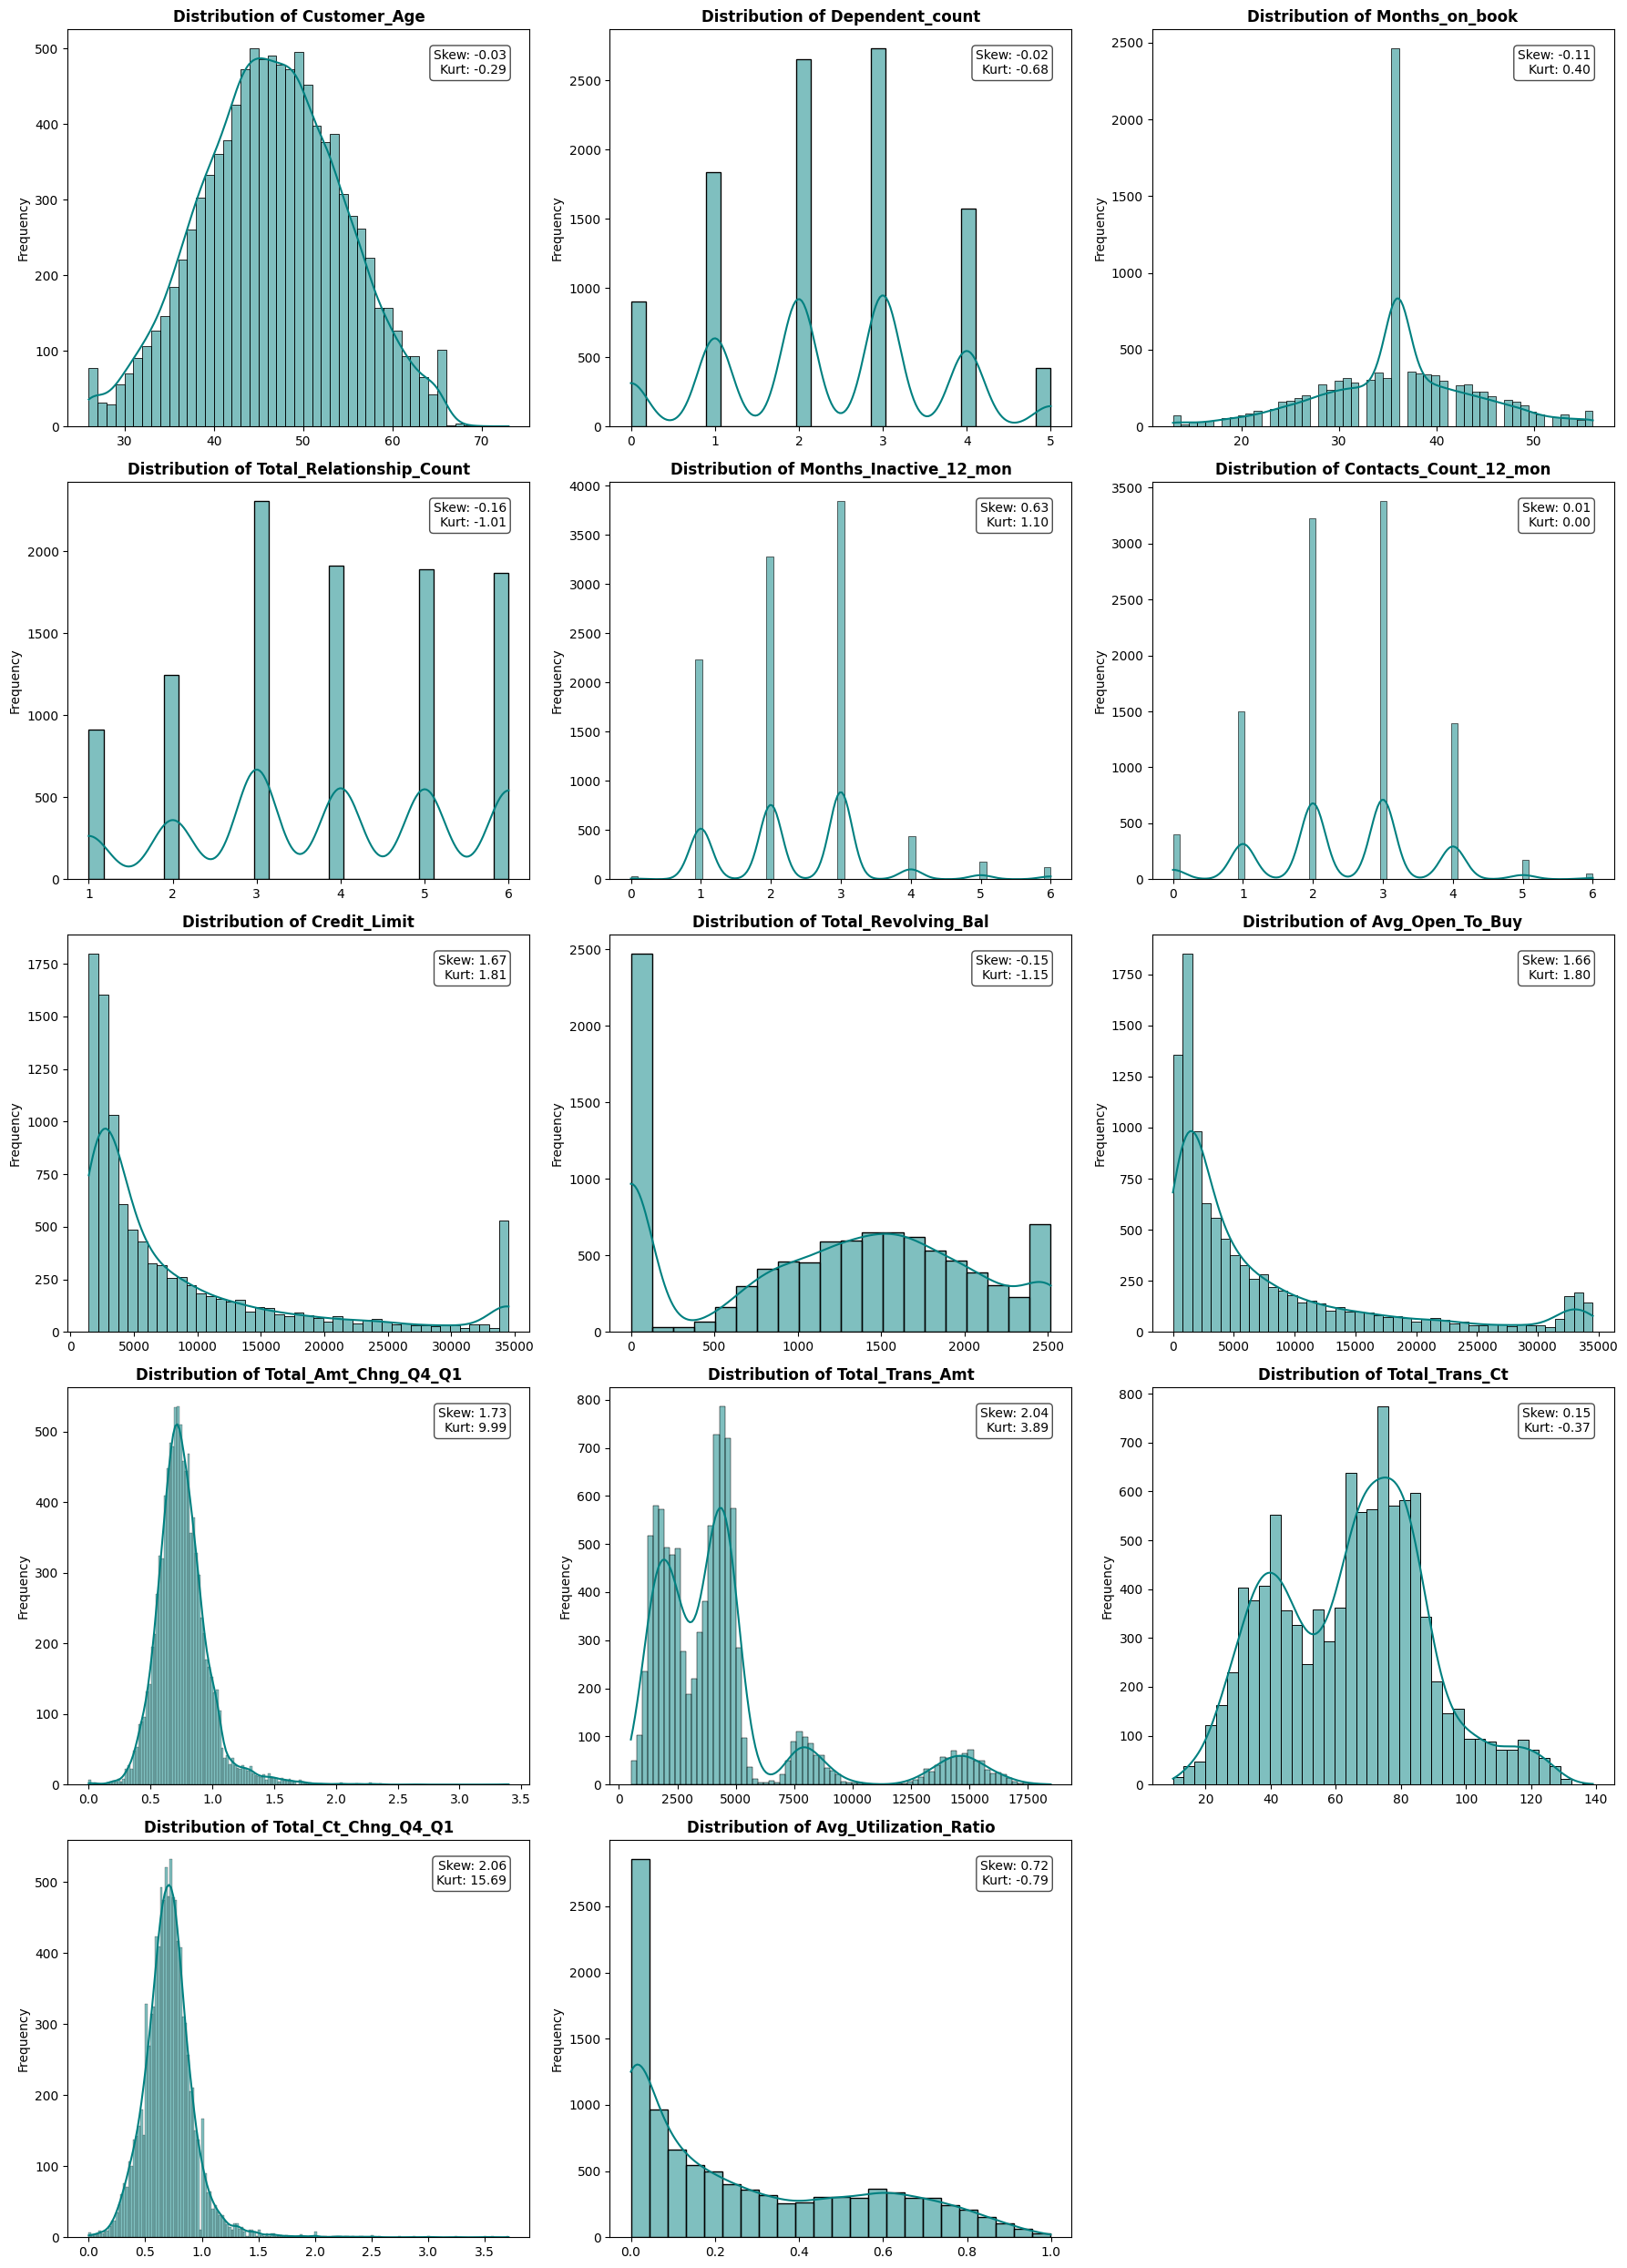

In [16]:
cols_to_plot = data.select_dtypes(include=['number']).columns.drop('CLIENTNUM')
n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    skew_val = data[col].skew()
    kurt_val = data[col].kurt()
    
    sns.histplot(data[col], kde=True, ax=axes[i], color='teal')
    
    textstr = f'Skew: {skew_val:.2f}\nKurt: {kurt_val:.2f}'
    props = dict(boxstyle='round', facecolor='white', alpha=0.7)
    axes[i].text(0.95, 0.95, textstr, transform=axes[i].transAxes, fontsize=10,
                 verticalalignment='top', horizontalalignment='right', bbox=props)
    
    axes[i].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

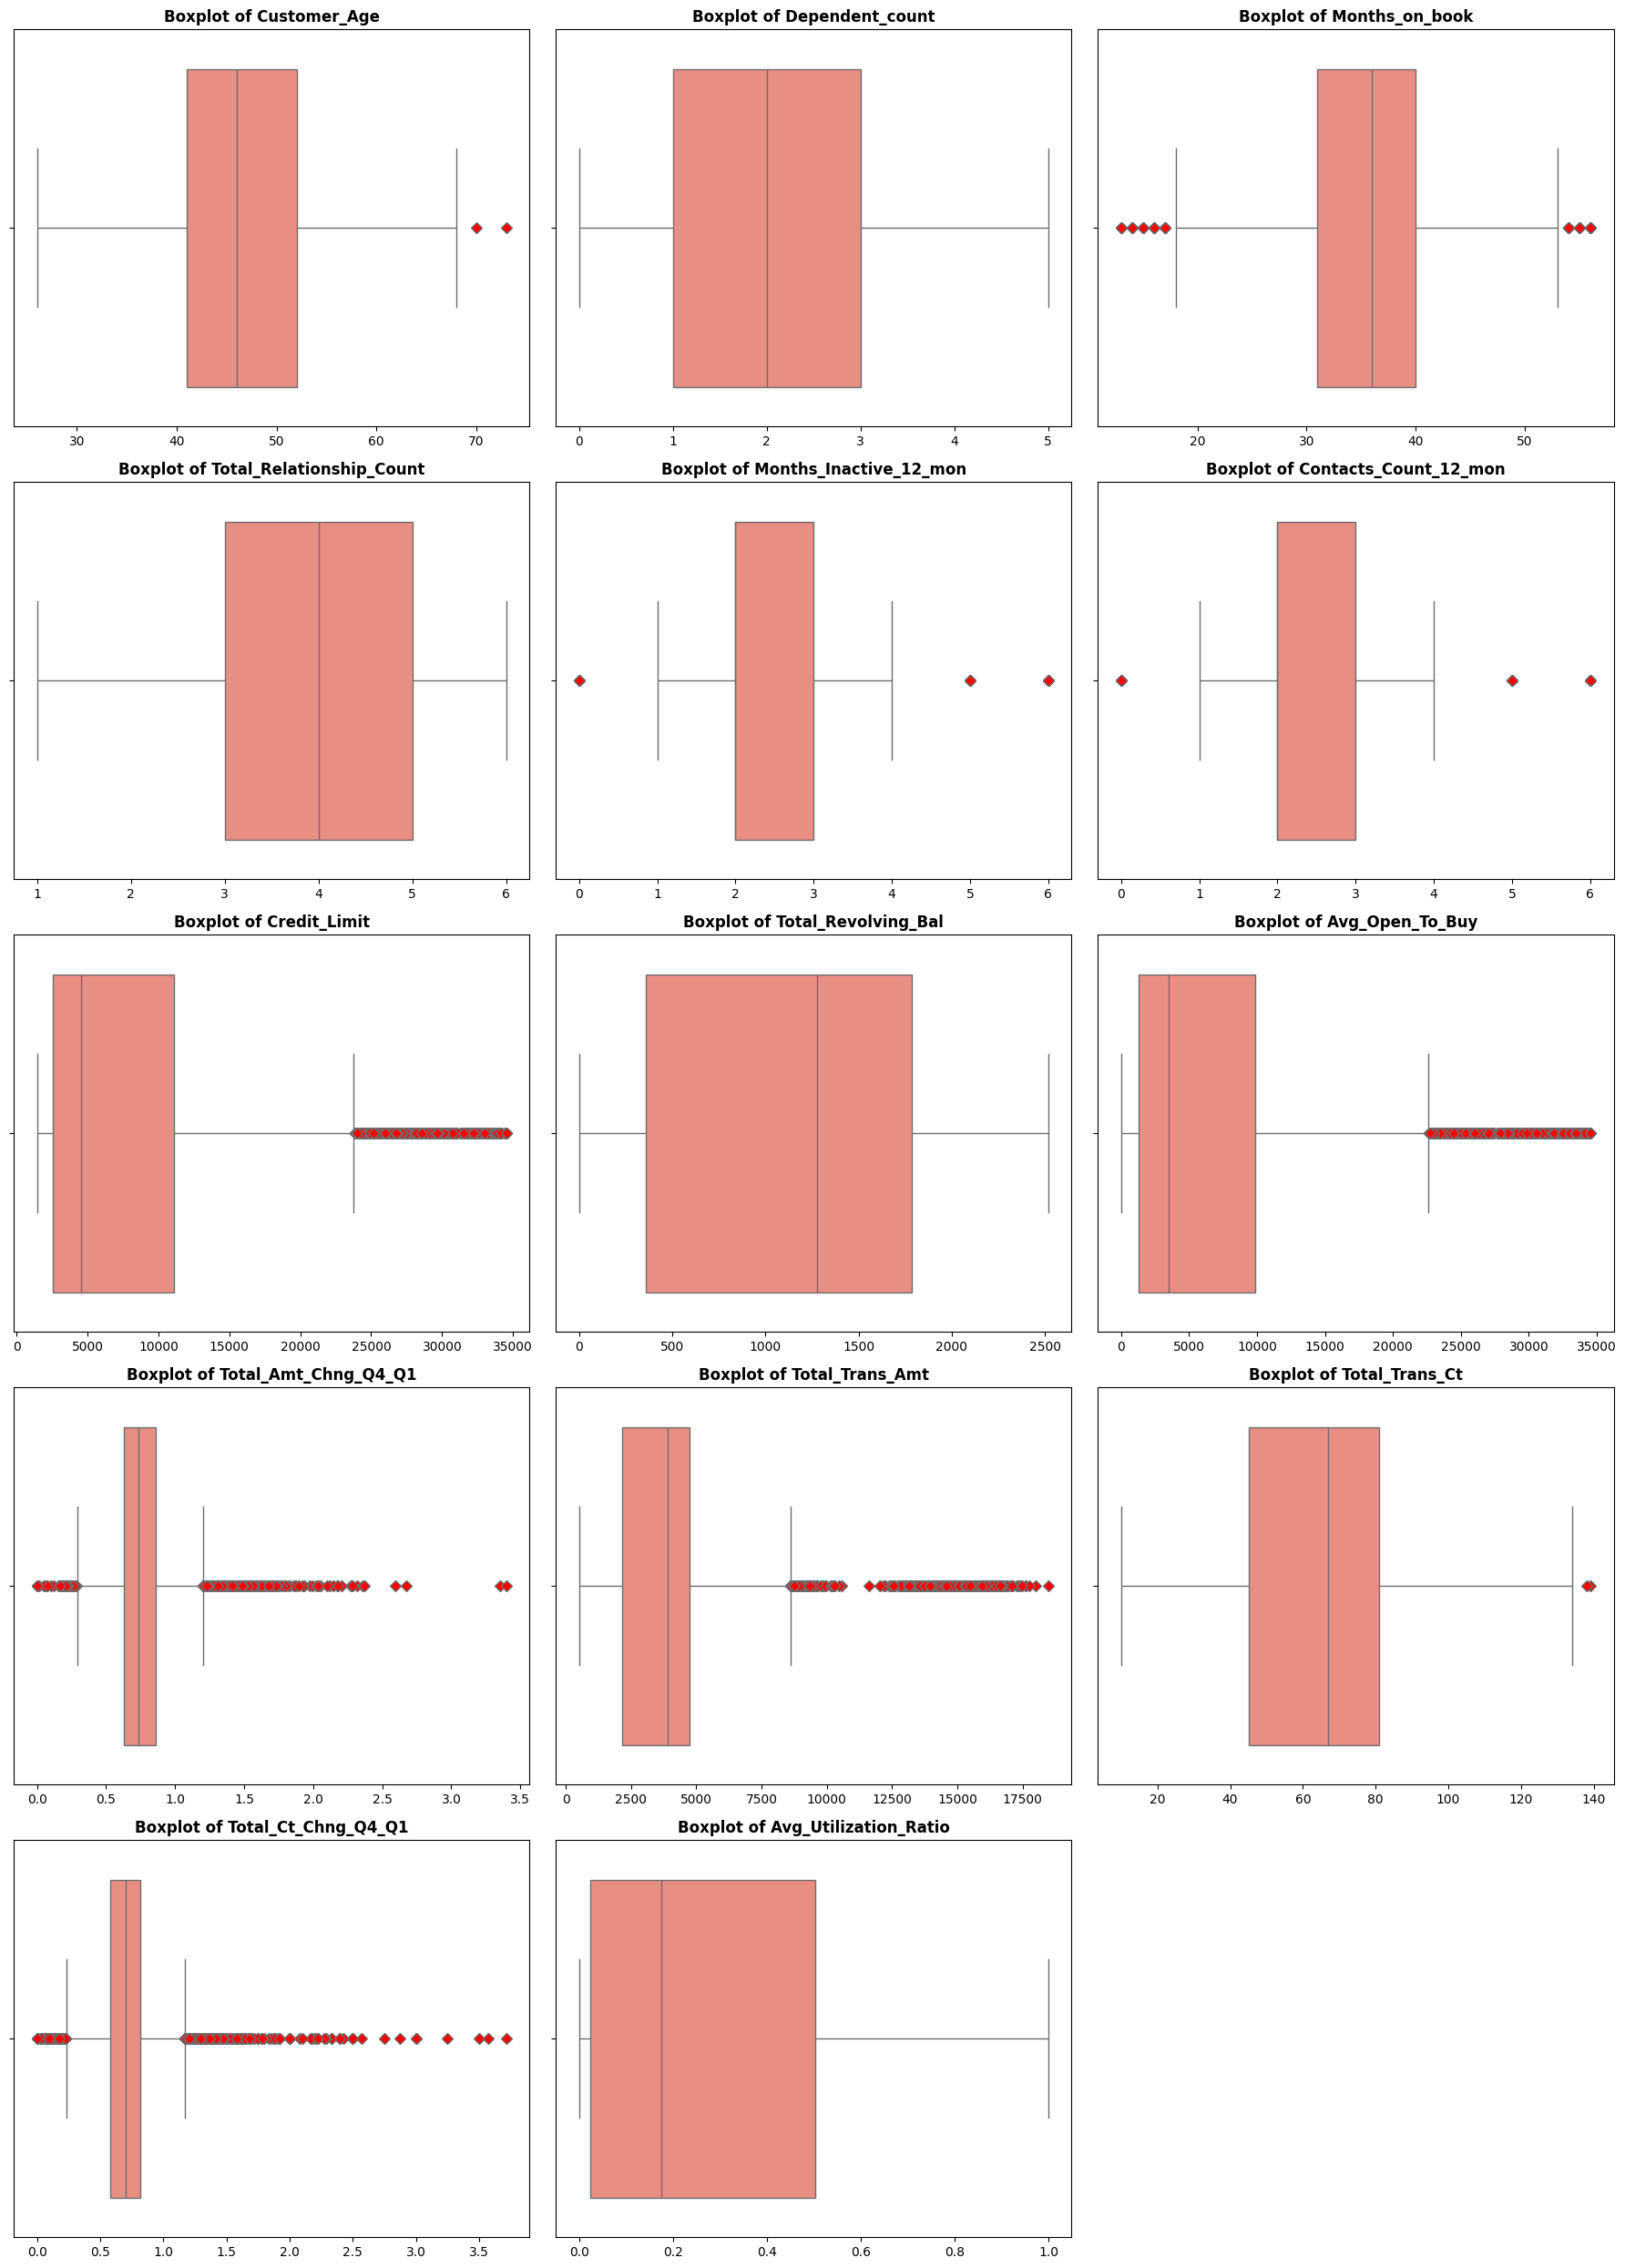

In [17]:
cols_to_plot = data.select_dtypes(include=['number']).columns.drop('CLIENTNUM')
n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(x=data[col], ax=axes[i], color='salmon', flierprops=dict(markerfacecolor='r', marker='D'))
    
    axes[i].set_title(f'Boxplot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

------------------

The columns Total_Amt_Chng_Q4_Q1 and Total_Ct_Chng_Q4_Q1 represent a Loss of Granularity. These columns are indicators of changes in a client's spending habits over time, specifically comparing the fourth quarter (Q4) to the first quarter (Q1). The problem is that the dataset does not contain specific values for Q4 and Q1, so it remains unknown what actual amount the change value indicates.

------------

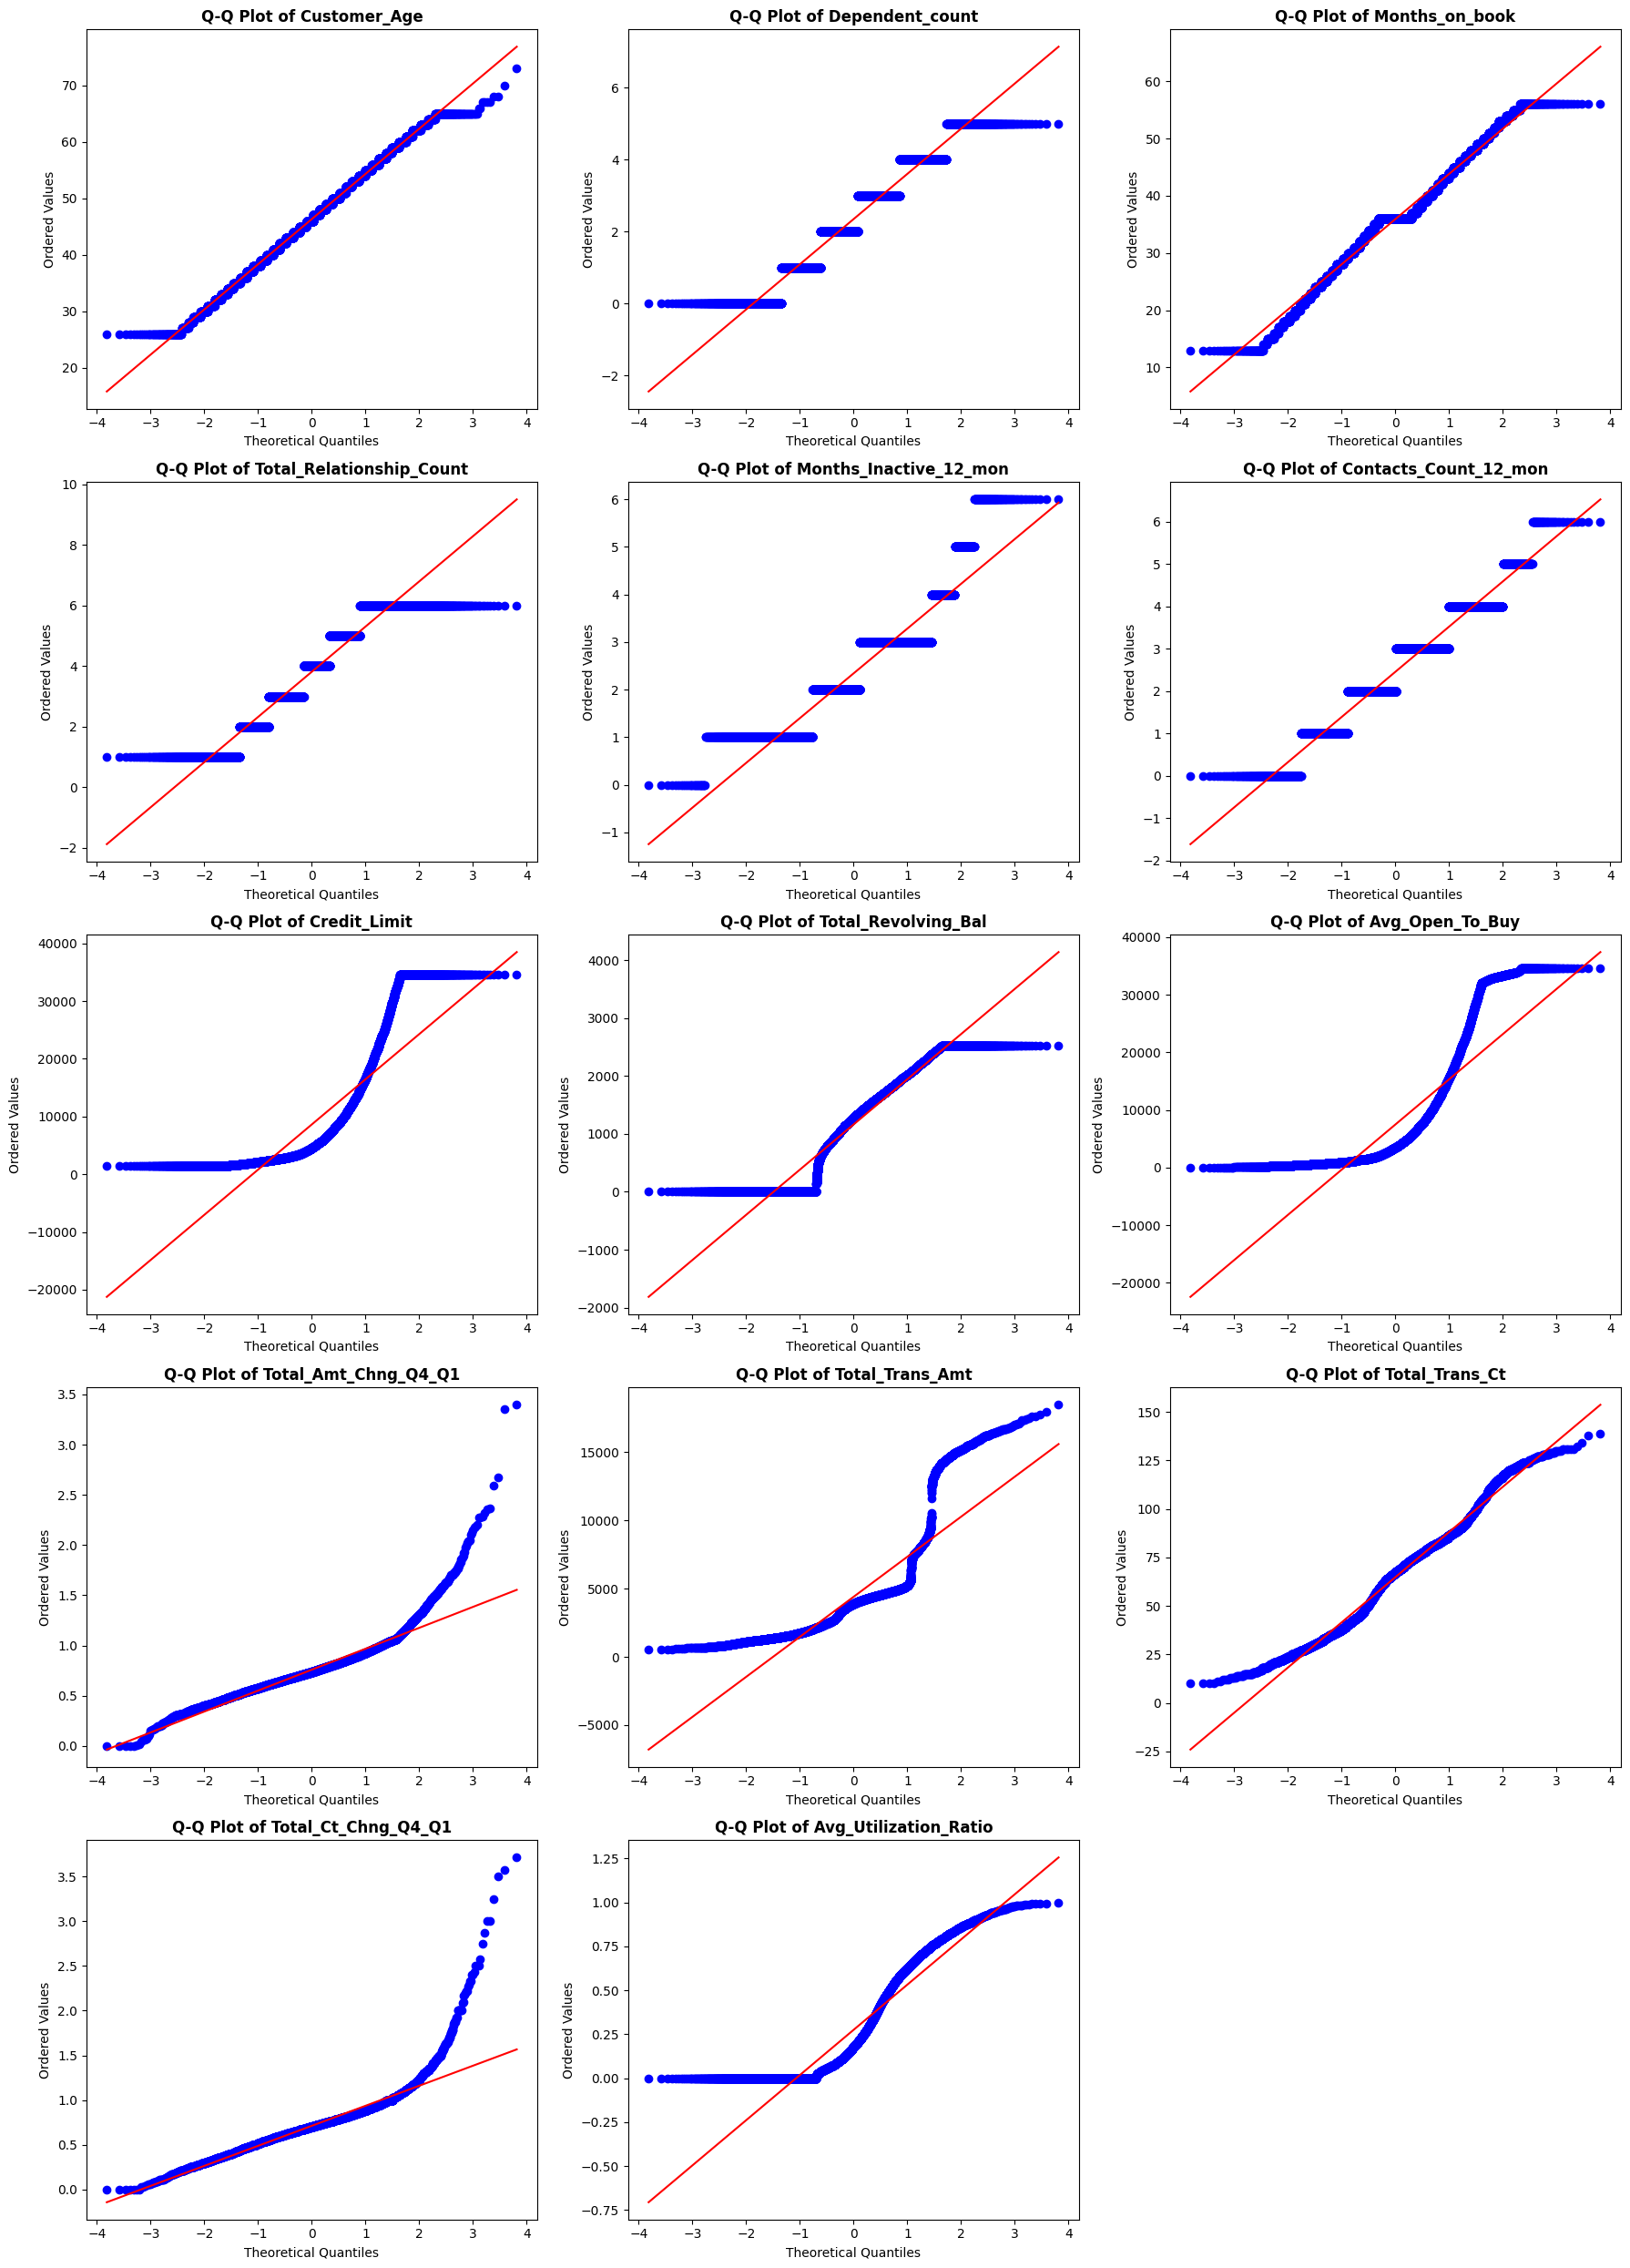

In [18]:
cols_to_plot = data.select_dtypes(include=['number']).columns.drop('CLIENTNUM')
n_cols = 3
n_rows = math.ceil(len(cols_to_plot) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    stats.probplot(data[col], dist="norm", plot=axes[i])
    
    axes[i].set_title(f'Q-Q Plot of {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Theoretical Quantiles')
    axes[i].set_ylabel('Ordered Values')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Categorical columns

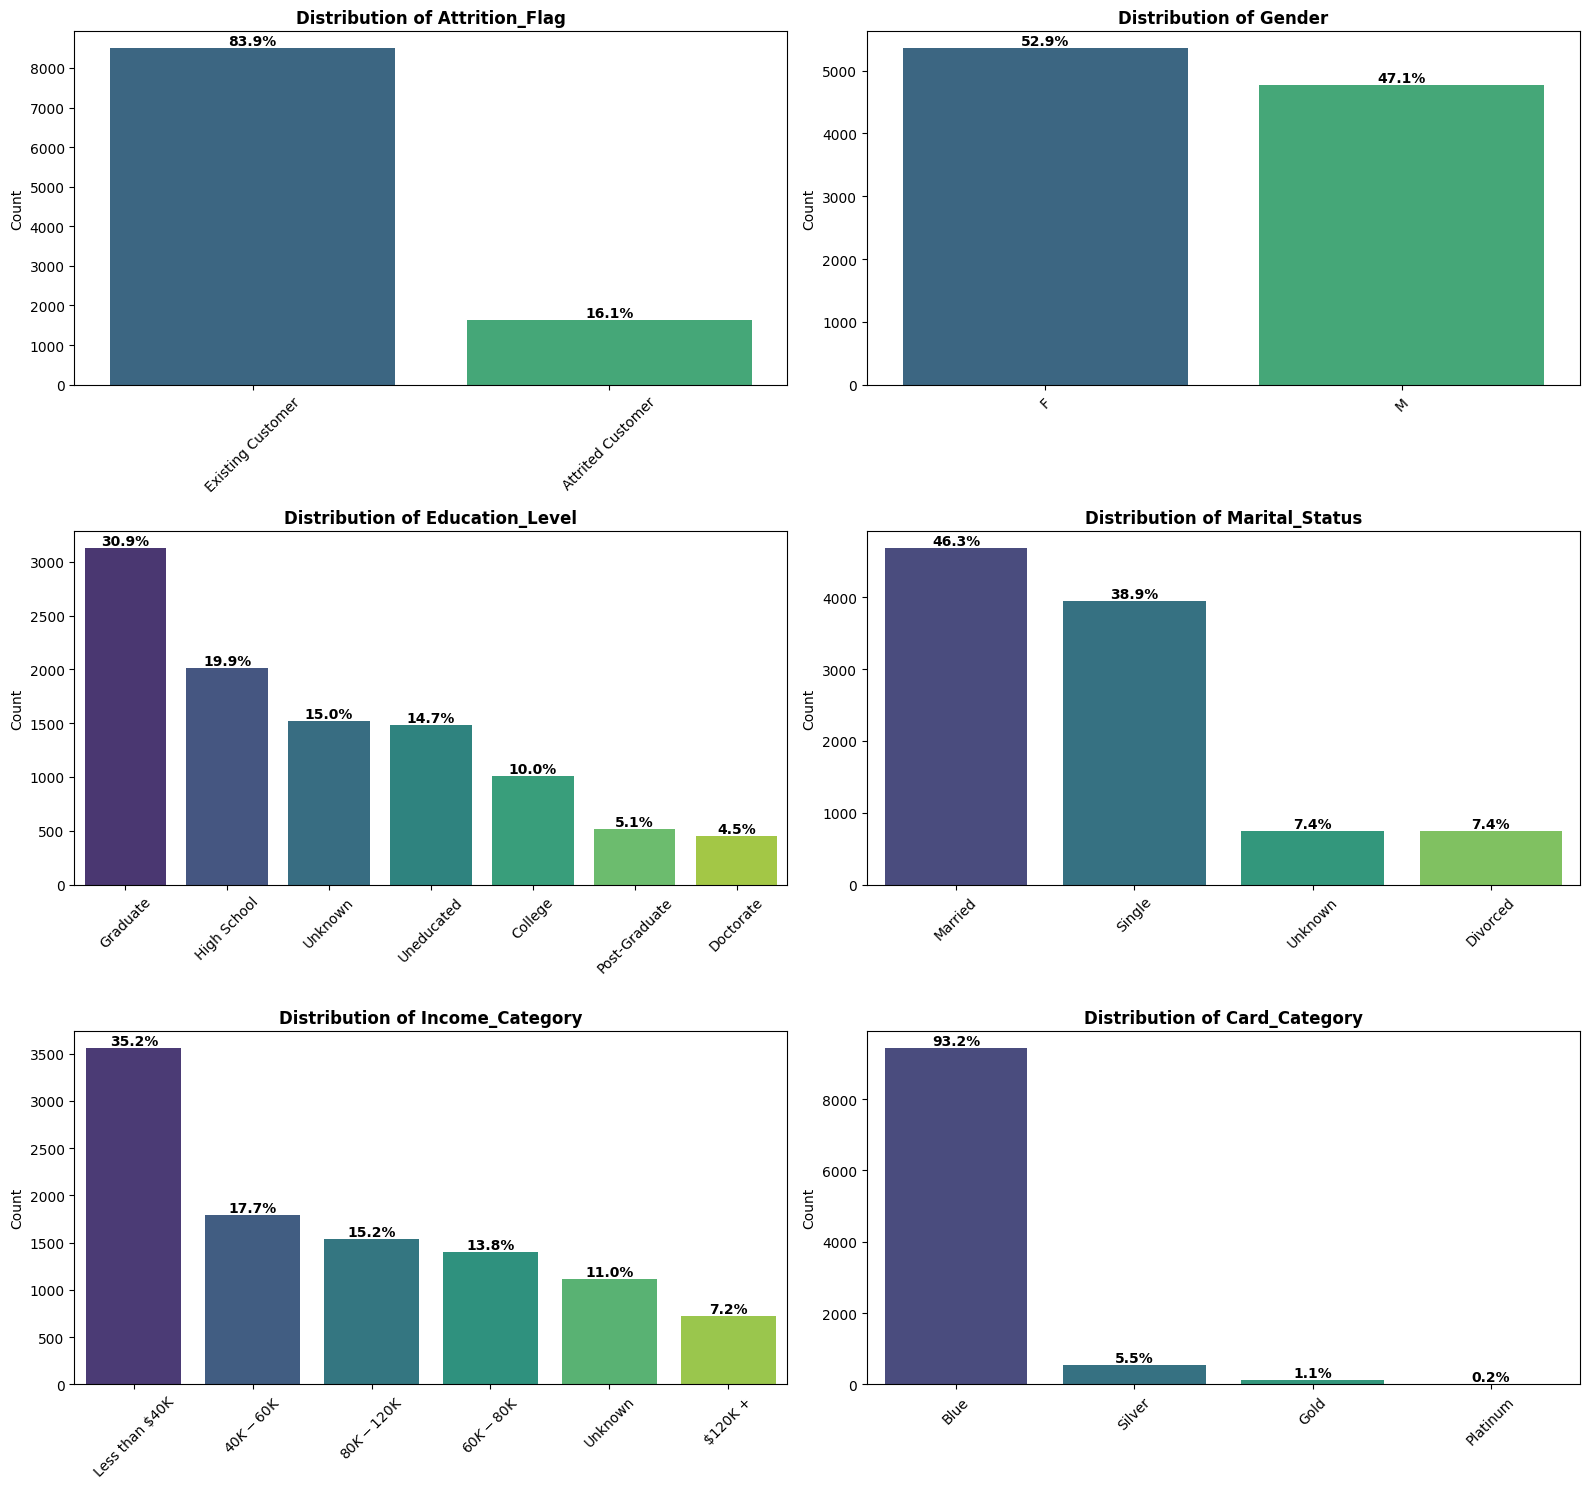

In [19]:
warnings.filterwarnings('ignore')

categorical_cols = data.select_dtypes(include=['object']).columns
total_rows = len(data)

n_cols = 2
n_rows = math.ceil(len(categorical_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    order = data[col].value_counts().index
    sns.countplot(data=data, x=col, ax=ax, palette='viridis', order=order)
    
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total_rows)
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.set_xlabel('')
    ax.set_ylabel('Count')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Ovdje se vidi primjer nekompletnosti (Completeness) podataka, gdje oznaka "Unknown" kod ordinalnih tipova atributa predstavlja šum. Kod Educational Level ovi uzorci mogu biti visokoobrazovani stručnjaci ili ljudi bez škole, a taj podatak drastično mijenja profil klijenta. Kod Income Category je situacija još teža jer ostale kategorije praktično obuhvataju sve moguće vrijednosti, od "Less than 40K" do "120K+", što znači da ovo nije neka skrivena (nova) kategorija korisnika, već grupa ljudi koja nije željela dati informaciju.

# III - NORMALITY TEST

In [20]:

cols_to_test = data.select_dtypes(include=['number']).columns.drop('CLIENTNUM')

results = []

for col in cols_to_test:
    clean_data = data[col].dropna()
    
    # 1. Shapiro-Wilk test
    stat_sw, p_sw = stats.shapiro(clean_data)
    
    # 2. Kolmogorov-Smirnov
    std_data = (clean_data - clean_data.mean()) / clean_data.std()
    stat_ks, p_ks = stats.kstest(std_data, 'norm')
    
    # 3. D’Agostino–Pearson
    stat_dp, p_dp = stats.normaltest(clean_data)
    
    results.append({
        'Variable': col,
        'Shapiro-Wilk (p)': f"{p_sw:.10f}",
        'Kolmogorov-Smirnov (p)': f"{p_ks:.10f}",
        'D’Agostino-Pearson (p)': f"{p_dp:.10f}"
    })

normality_df = pd.DataFrame(results)
print(normality_df)

                    Variable Shapiro-Wilk (p) Kolmogorov-Smirnov (p)  \
0               Customer_Age     0.0000000000           0.0000002234   
1            Dependent_count     0.0000000000           0.0000000000   
2             Months_on_book     0.0000000000           0.0000000000   
3   Total_Relationship_Count     0.0000000000           0.0000000000   
4     Months_Inactive_12_mon     0.0000000000           0.0000000000   
5      Contacts_Count_12_mon     0.0000000000           0.0000000000   
6               Credit_Limit     0.0000000000           0.0000000000   
7        Total_Revolving_Bal     0.0000000000           0.0000000000   
8            Avg_Open_To_Buy     0.0000000000           0.0000000000   
9       Total_Amt_Chng_Q4_Q1     0.0000000000           0.0000000000   
10           Total_Trans_Amt     0.0000000000           0.0000000000   
11            Total_Trans_Ct     0.0000000000           0.0000000000   
12       Total_Ct_Chng_Q4_Q1     0.0000000000           0.000000

The obtained results are not the most representative. As previously seen in the histograms, it was expected that certain columns would receive mathematical confirmation of their deviation from the normal distribution; however, due to the large number of samples in the dataset, the sensitivity of the algorithms increased, and with it, the normalization standard that a given distribution must meet to be considered normal. Only Contacts_Count_12_mon passed, having a 0.01 Skew and 0.00 Kurtosis, specifically in the test that relies on these two values, while failing other parts as a discrete variable.<br>
In this case, it would be useful to try the Bootstrapping method.

# IV - LEVENE'S TEST FOR HOMOSCEDASTICITY, T-TEST, ANOVA

Example: Total_Trans_Amt (total spending) in relation to Gender or Attrition_Flag (client status).

In [21]:
existing_spend = data[data['Attrition_Flag'] == 'Existing Customer']['Total_Trans_Amt']
attrited_spend = data[data['Attrition_Flag'] == 'Attrited Customer']['Total_Trans_Amt']

# 'median' is used because the data is not normal distributed
stat, p_val = levene(existing_spend, attrited_spend, center='median')

print(f"Levene stats: {stat:.4f}")
print(f"p-value: {p_val:.10f}")

alpha = 0.05
if p_val < alpha:
    print("heteroscedasticity")
else:
    print("Homoscedasticity")

Levene stats: 99.4047
p-value: 0.0000000000
heteroscedasticity


Analysis of homogeneity of variance using Levene's test on groups defined by the Attrition_Flag variable resulted in a p-value of 0.0000. This confirmed significant heteroscedasticity in spending between loyal clients and those who closed their accounts.

---------------------------------

Since the conditions of normality and homoscedasticity are not met, the t-test cannot be used. The alternative is Welch's t-test.

In [22]:
# Welch's t-test (equal_var=False)
t_stat, p_val = stats.ttest_ind(existing_spend, attrited_spend, equal_var=False)

print(f"Welch's T-stat: {t_stat:.4f}")
print(f"p-value: {p_val:.10f}")

Welch's T-stat: 22.6859
p-value: 0.0000000000


The high t-value indicates that the difference between the two groups is very large relative to the variability within the groups themselves. A zero p-value indicates that the difference between the two client groups is not accidental.

In [23]:
means = data.groupby('Attrition_Flag')['Total_Trans_Amt'].mean()
print(means)

Attrition_Flag
Attrited Customer    3095.025814
Existing Customer    4654.655882
Name: Total_Trans_Amt, dtype: float64


-----------

ANOVA:

In [24]:
import pingouin as pg

# 1. Welch's ANOVA
welch_anova = pg.welch_anova(data=data, dv='Total_Trans_Amt', between='Card_Category')

print("--- WELCH'S ANOVA ---")
print(welch_anova)

# 2. Post-hoc test (Games-Howell)
posthoc = pg.pairwise_gameshowell(data=data, dv='Total_Trans_Amt', between='Card_Category')

print("\n--- GAMES-HOWELL POST-HOC TEST ---")
print(posthoc[['A', 'B', 'mean(A)', 'mean(B)', 'diff', 'pval']])

--- WELCH'S ANOVA ---
          Source  ddof1      ddof2          F         p-unc       np2
0  Card_Category      3  79.551473  69.183824  4.143059e-22  0.039585

--- GAMES-HOWELL POST-HOC TEST ---
          A         B      mean(A)      mean(B)         diff          pval
0      Blue      Gold  4225.406740  7685.612069 -3460.205329  3.176015e-12
1      Blue  Platinum  4225.406740  8999.750000 -4774.343260  1.892603e-03
2      Blue    Silver  4225.406740  6590.482883 -2365.076143  1.167955e-13
3      Gold  Platinum  7685.612069  8999.750000 -1314.137931  6.859402e-01
4      Gold    Silver  7685.612069  6590.482883  1095.129186  9.697926e-02
5  Platinum    Silver  8999.750000  6590.482883  2409.267117  1.722684e-01


Although Welch's ANOVA confirmed that the card level affects spending, a detailed Games-Howell post-hoc analysis revealed an interesting phenomenon: a statistically significant difference exists exclusively between the 'Blue' card and all other levels. Between 'Silver', 'Gold', and 'Platinum' users, there is no statistically significant difference in average spending, despite the different names and presumably different maintenance costs associated with those cards.

# V - ATTRIBUTE CORRELATION, REDUNDANCY, AND MULTICOLLINEARITY

## Numerical

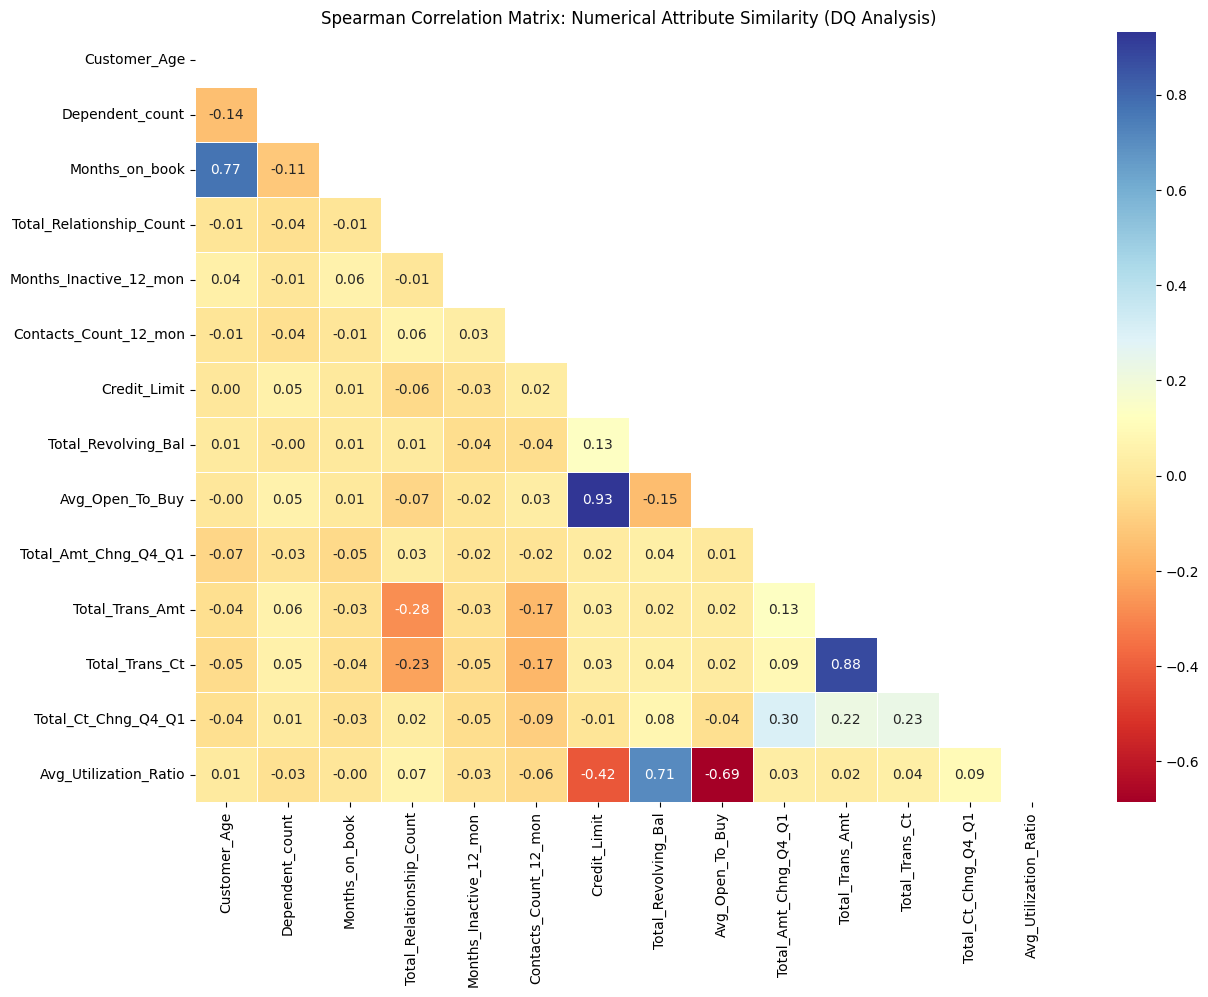

In [25]:
numerical_data = data.select_dtypes(include='number').drop('CLIENTNUM', axis = 1)

spearman_corr = numerical_data.corr(method='spearman')
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(spearman_corr, 
            mask=mask, 
            annot=True, 
            cmap='RdYlBu', 
            fmt=".2f", 
            linewidths=0.5)

plt.title("Spearman Correlation Matrix: Numerical Attribute Similarity (DQ Analysis)")
plt.show()

1. Consistency
   Total_Trans_Amt vs Total_Trans_Ct (0.88): It is logical that a higher number of transactions generates a higher total sum. If this number were low, it would be an alarm that transaction data is either incomplete or incorrectly recorded. These two columns can later be used to form a new feature representing their ratio.<br>
   Customer_Age vs Months_on_book (0.77): This confirms chronological logic; younger users cannot spend as long a period with the bank as older ones can. The client data is not randomly generated but follows a life cycle.
2. Validity
   Avg_Utilization_Ratio vs Credit_Limit (-0.42) vs Total_Revolving_Bal (0.71) vs Avg_Open_To_Buy (-0.69): If we look again at the formula for calculating this ratio, it makes perfect sense that the value decreases as the denominator increases and increases as the numerator increases, and vice-versa. The high negative correlation with Avg_Open_To_Buy likely stems from its strong correlation with Credit_Limit (0.93). <br>
   Credit_Limit vs Avg_Open_To_Buy (0.93): One can see from the histograms that their distributions and value ranges are identical, except that Avg_Open_To_Buy has a lower minimum (0). With such a high correlation, this is a clear candidate for removal during the Feature Selection phase.
   

-------------------

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if 'CLIENTNUM' in numeric_cols: numeric_cols.remove('CLIENTNUM')

X_vif = data[numeric_cols].dropna()

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                     feature        VIF
6               Credit_Limit        inf
7        Total_Revolving_Bal        inf
8            Avg_Open_To_Buy        inf
0               Customer_Age  75.090540
2             Months_on_book  56.437261
11            Total_Trans_Ct  23.199897
9       Total_Amt_Chng_Q4_Q1  13.940730
12       Total_Ct_Chng_Q4_Q1  11.808382
10           Total_Trans_Amt   8.635042
3   Total_Relationship_Count   7.476147
4     Months_Inactive_12_mon   6.084906
13     Avg_Utilization_Ratio   5.760124
5      Contacts_Count_12_mon   5.538823
1            Dependent_count   4.058599


A generally high multicollinearity among variables in the dataset has been observed. The validity of these results, despite the non-normal distribution, is justified by their consistency with the Spearman correlation matrix, as well as the fact that VIF (Variance Inflation Factor) diagnoses the proportion of shared variance independently of the residual distribution. <br>
High VIF values (including infinite values) are not unexpected, given that most attributes are structurally and mathematically dependent (e.g., derived values for limits and debt). This test serves as a final validation prior to the Feature Reduction step, in order to eliminate redundancy that could destabilize future models.

## Categorical

In [27]:
def get_cramers_v(var1, var2):
    confusion_matrix = pd.crosstab(var1, var2)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    if min((kcorr - 1), (rcorr - 1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

cat_columns = data.select_dtypes(include=['object']).columns.tolist()

print(f"--- Categorical Dependency Analysis (DQ Consistency Check) ---")
print(f"{'Variable A':<25} | {'Variable B':<25} | {'p-value':<10} | {'Cramér\'s V'}")
print("-" * 85)

for col1, col2 in itertools.combinations(cat_columns, 2):
    contingency_table = pd.crosstab(data[col1], data[col2])
    _, p, _, _ = chi2_contingency(contingency_table)
    
    v_score = get_cramers_v(data[col1], data[col2])
    
    print(f"{col1:<25} | {col2:<25} | {p:<10.4e} | {v_score:.4f}")

--- Categorical Dependency Analysis (DQ Consistency Check) ---
Variable A                | Variable B                | p-value    | Cramér's V
-------------------------------------------------------------------------------------
Attrition_Flag            | Gender                    | 1.9636e-04 | 0.0356
Attrition_Flag            | Education_Level           | 5.1489e-02 | 0.0254
Attrition_Flag            | Marital_Status            | 1.0891e-01 | 0.0174
Attrition_Flag            | Income_Category           | 2.5002e-02 | 0.0278
Attrition_Flag            | Card_Category             | 5.2524e-01 | 0.0000
Gender                    | Education_Level           | 2.9498e-01 | 0.0113
Gender                    | Marital_Status            | 2.7524e-01 | 0.0093
Gender                    | Income_Category           | 0.0000e+00 | 0.8393
Gender                    | Card_Category             | 3.6049e-16 | 0.0843
Education_Level           | Marital_Status            | 2.5451e-01 | 0.0107
Education_L

Although a high correlation is only observed between the Gender and Income_Category categories, it should be noted that these results are not fully representative due to the presence of Unknown values in certain attributes, meaning they provide a skewed representation of reality.<br>
However, a useful piece of information that can be extracted is the weak correlation of categorical columns with Attrition_Flag, indicating that these attributes would carry little predictive power when applying machine learning algorithms.<br>
It would be good practice to repeat this test with the Unknown samples removed to assess their specific impact.

In [28]:
df_mi = data.copy()

for col in df_mi.select_dtypes(include=['object']).columns:
    df_mi[col] = df_mi[col].astype('category').cat.codes

X = df_mi.drop('Attrition_Flag', axis=1)
y = df_mi['Attrition_Flag']

discrete_features = [X.columns.get_loc(col) for col in X.columns if data[col].dtype == 'object']

mi_scores = mutual_info_classif(X, y, discrete_features=discrete_features, random_state=42)

mi_results = pd.Series(mi_scores, name="MI Score", index=X.columns)
mi_results = mi_results.sort_values(ascending=False)

print("--- Mutual Information Scores (Target: Attrition_Flag) ---")
print(mi_results)

--- Mutual Information Scores (Target: Attrition_Flag) ---
Total_Trans_Amt             0.158639
Total_Trans_Ct              0.106940
Total_Ct_Chng_Q4_Q1         0.098479
Total_Revolving_Bal         0.087368
Avg_Utilization_Ratio       0.050467
Total_Amt_Chng_Q4_Q1        0.032574
Contacts_Count_12_mon       0.027152
Months_Inactive_12_mon      0.023079
Avg_Open_To_Buy             0.020682
Total_Relationship_Count    0.015011
Credit_Limit                0.006603
CLIENTNUM                   0.004449
Dependent_count             0.001477
Gender                      0.000697
Income_Category             0.000647
Education_Level             0.000587
Marital_Status              0.000299
Card_Category               0.000104
Months_on_book              0.000000
Customer_Age                0.000000
Name: MI Score, dtype: float64


The results of the Mutual Information test confirm that transactional data possesses the highest information capacity relative to the target variable, while demographic attributes show zero or negligible informativeness. This justifies focusing on behavioral data in further quality analysis.

--------------------

Since Feature Reduction is not the primary focus of this paper, yet must be performed for further testing, columns will be intuitively removed based on the analysis conducted so far, rather than using specific methods belonging to that field.

In [29]:
data_reduced = data.drop(['CLIENTNUM','Gender','Education_Level','Marital_Status','Card_Category','Income_Category','Credit_Limit','Months_on_book','Customer_Age'], axis = 1)

In [30]:
data_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Dependent_count           10127 non-null  int64  
 2   Total_Relationship_Count  10127 non-null  int64  
 3   Months_Inactive_12_mon    10127 non-null  int64  
 4   Contacts_Count_12_mon     10127 non-null  int64  
 5   Total_Revolving_Bal       10127 non-null  int64  
 6   Avg_Open_To_Buy           10127 non-null  float64
 7   Total_Amt_Chng_Q4_Q1      10127 non-null  float64
 8   Total_Trans_Amt           10127 non-null  int64  
 9   Total_Trans_Ct            10127 non-null  int64  
 10  Total_Ct_Chng_Q4_Q1       10127 non-null  float64
 11  Avg_Utilization_Ratio     10127 non-null  float64
dtypes: float64(4), int64(7), object(1)
memory usage: 949.5+ KB


---------------

# VI - SIMILARITY MEASURES

In [31]:

def test_similarity(df):
    X = data.select_dtypes(include=[np.number]).dropna()
    X_scaled = StandardScaler().fit_transform(X)
    
    sample = X_scaled[np.random.choice(X_scaled.shape[0], 1000, replace=False)]
    dists = pdist(sample, metric='euclidean')
    return np.mean(dists), np.std(dists)

avg_orig, std_orig = test_similarity(data) 
avg_clean, std_clean = test_similarity(data_reduced) 

print(f"Original dataset - average distance: {avg_orig:.4f} (+/- {std_orig:.4f})")
print(f"Reduced dataset - average distance: {avg_clean:.4f} (+/- {std_clean:.4f})")

Original dataset - average distance: 5.3386 (+/- 1.3206)
Reduced dataset - average distance: 5.2226 (+/- 1.4051)


Comparison of similarity measures between the original and the reduced dataset indicates an increase in the mean Euclidean distance (from 5.23 to 5.32) and standard deviation (from 1.32 to 1.43). These results confirm a successful refinement of the data space: by eliminating irrelevant demographic attributes, differences in the financial behavior of clients have become more pronounced.<br>
The higher variance in distances within the reduced set suggests that the remaining attributes are the true carriers of discriminative power, whereas previous results were artificially smoothed due to the presence of redundant variables.

In [32]:
from sklearn.metrics import pairwise_distances

cat_cols = ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']
df_cat = data[cat_cols].copy()

for col in df_cat.columns:
    df_cat[col] = pd.factorize(df_cat[col])[0]

sample_cat = df_cat.sample(1000, random_state=42)
smc_dist = pairwise_distances(sample_cat, metric='matching')

smc_similarity = 1 - smc_dist

tri_indices = np.triu_indices_from(smc_similarity, k=1)
avg_smc = np.mean(smc_similarity[tri_indices])

print(f"--- Simple Matching Coefficient (SMC) ---")
print(f"Avegare similarity (SMC): {avg_smc:.4f}")

--- Simple Matching Coefficient (SMC) ---
Avegare similarity (SMC): 0.4282


Comparison of samples based on categorical variables, which are primarily demographic in nature, indicates a moderate heterogeneity within the dataset, which is a positive sign. However, as previously demonstrated, this diversity does not influence Attrition.

-----------------------------

In [33]:
from scipy.stats import chi2

X = data_reduced.drop(columns=['Attrition_Flag'])

cov_matrix = np.cov(X.values.T)
inv_cov_matrix = np.linalg.inv(cov_matrix)
mean_distr = np.mean(X.values, axis=0)

def mahalanobis_distance(x, mean, inv_cov):
    diff = x - mean
    return np.sqrt(diff.dot(inv_cov).dot(diff.T))

data_reduced['Mahalanobis'] = [mahalanobis_distance(row, mean_distr, inv_cov_matrix) for row in X.values]

p_value = 0.95
df = X.shape[1]
threshold = np.sqrt(chi2.ppf(p_value, df))

outliers = data_reduced[data_reduced['Mahalanobis'] > threshold].sort_values(by='Mahalanobis', ascending=False)

print(f"Outlier threshold (Chi-square {p_value}): {threshold:.4f}")
print(f"Outlier count: {len(outliers)} from {len(data_reduced)}")
print("\nTop 5 rarest profiles based on Mahalanobis:")
print(outliers[['Mahalanobis'] + X.columns.tolist()].head(5))

Outlier threshold (Chi-square 0.95): 4.4357
Outlier count: 751 from 10127

Top 5 rarest profiles based on Mahalanobis:
     Mahalanobis  Dependent_count  Total_Relationship_Count  \
12     15.053094                1                         3   
773    13.349228                0                         6   
269    13.345507                5                         3   
1      13.315971                5                         6   
8      12.764627                3                         5   

     Months_Inactive_12_mon  Contacts_Count_12_mon  Total_Revolving_Bal  \
12                        6                      0                    0   
773                       2                      3                 1927   
269                       3                      3                 1434   
1                         1                      2                  864   
8                         2                      0                 2517   

     Avg_Open_To_Buy  Total_Amt_Chng_Q4_Q1  Total_T

For the 751 identified outliers, an analyst could perform an individual or collective review to decide on their removal from the dataset. However, to prevent the study from straying too far from its core objective, to avoid blindly discarding users who make up 7.4% of the total samples, and to preserve the integrity of real-world variations in bank client behavior, these outliers will remain included in the dataset.

In [34]:
data_reduced = data_reduced.drop('Mahalanobis',axis = 1)

------------------------

# VII - QUALITY IMPROVEMENT - NORMALIZATION

In [35]:
data_normalized = data_reduced.copy()
num_cols = data_normalized.select_dtypes(include=[np.number]).columns

for col in num_cols:
    if (data_normalized[col] <= 0).any():
        shift = abs(data_normalized[col].min()) + 1
        data_to_transform = data_normalized[col] + shift
    else:
        data_to_transform = data_normalized[col]
    

    transformed_data, best_lambda = stats.boxcox(data_to_transform)
    data_normalized[col] = transformed_data
    

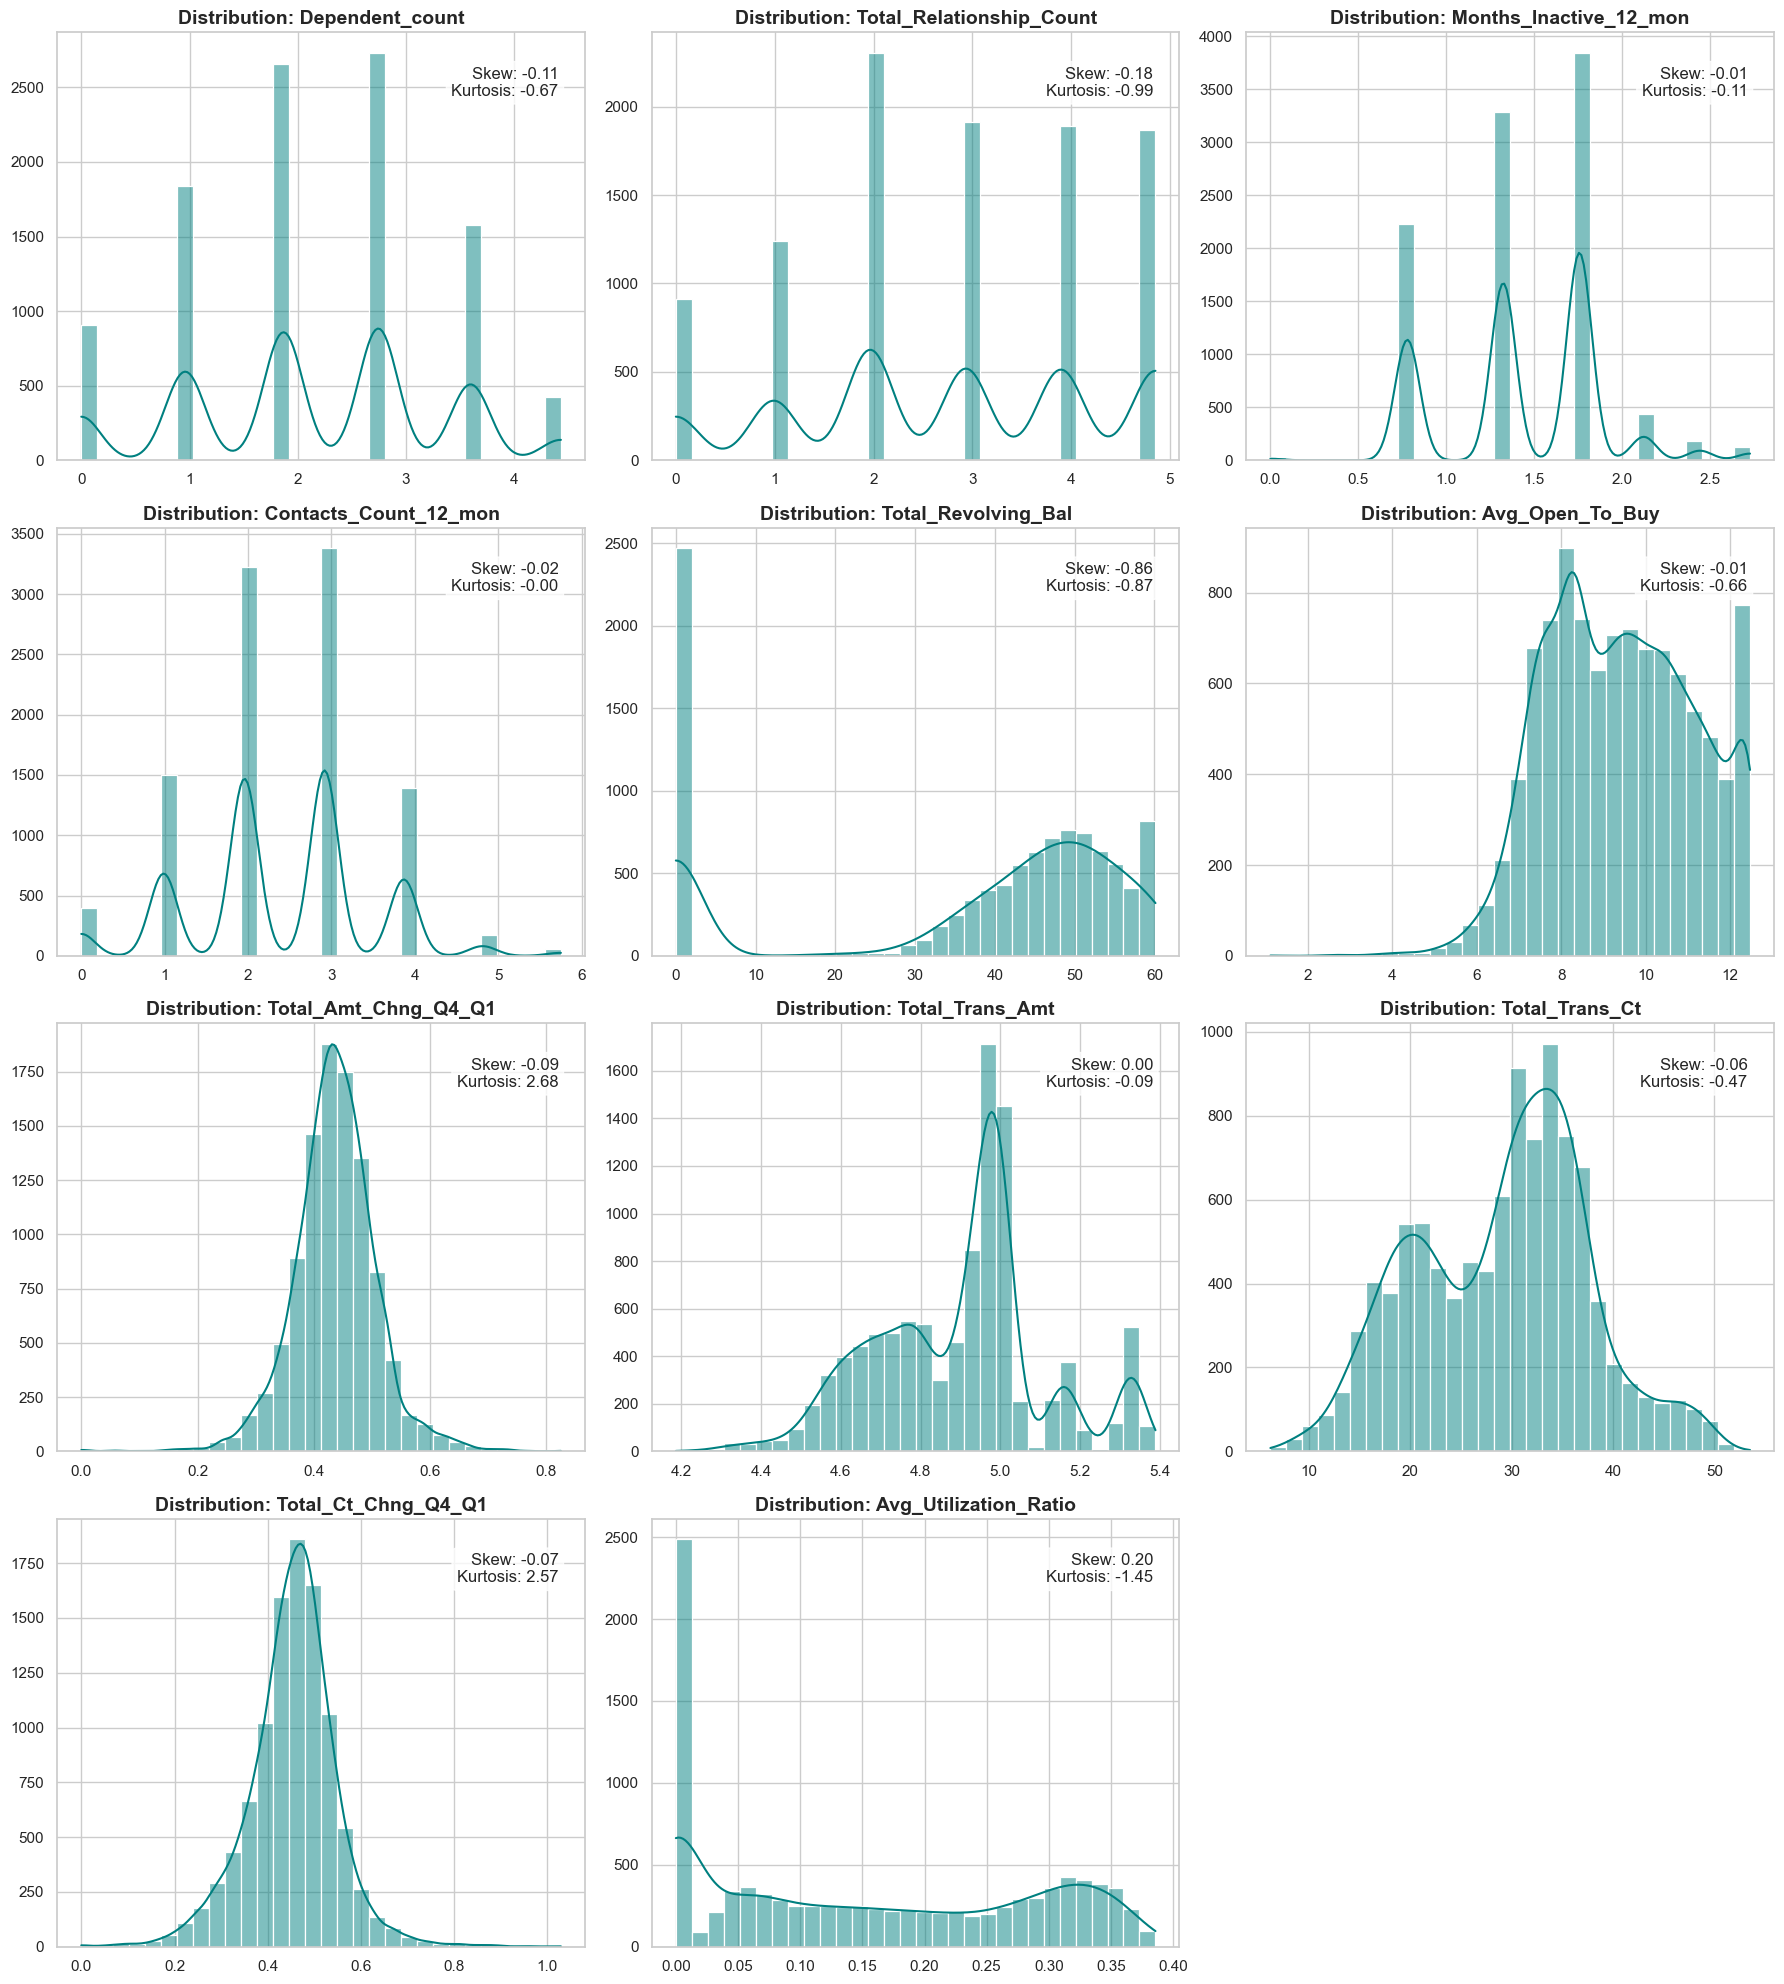

In [36]:
sns.set_theme(style="whitegrid")

num_cols = data_normalized.select_dtypes(include=[np.number]).columns
n_features = len(num_cols)

n_rows = (n_features + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    col_skew = data_normalized[col].skew()
    col_kurt = data_normalized[col].kurtosis() 
    
    sns.histplot(data_normalized[col], kde=True, ax=axes[i], color='teal', bins=30)
    
    axes[i].set_title(f'Distribution: {col}', fontsize=14, fontweight='bold')
    axes[i].text(0.95, 0.92, f'Skew: {col_skew:.2f}\nKurtosis: {col_kurt:.2f}', 
                 transform=axes[i].transAxes, verticalalignment='top', horizontalalignment='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

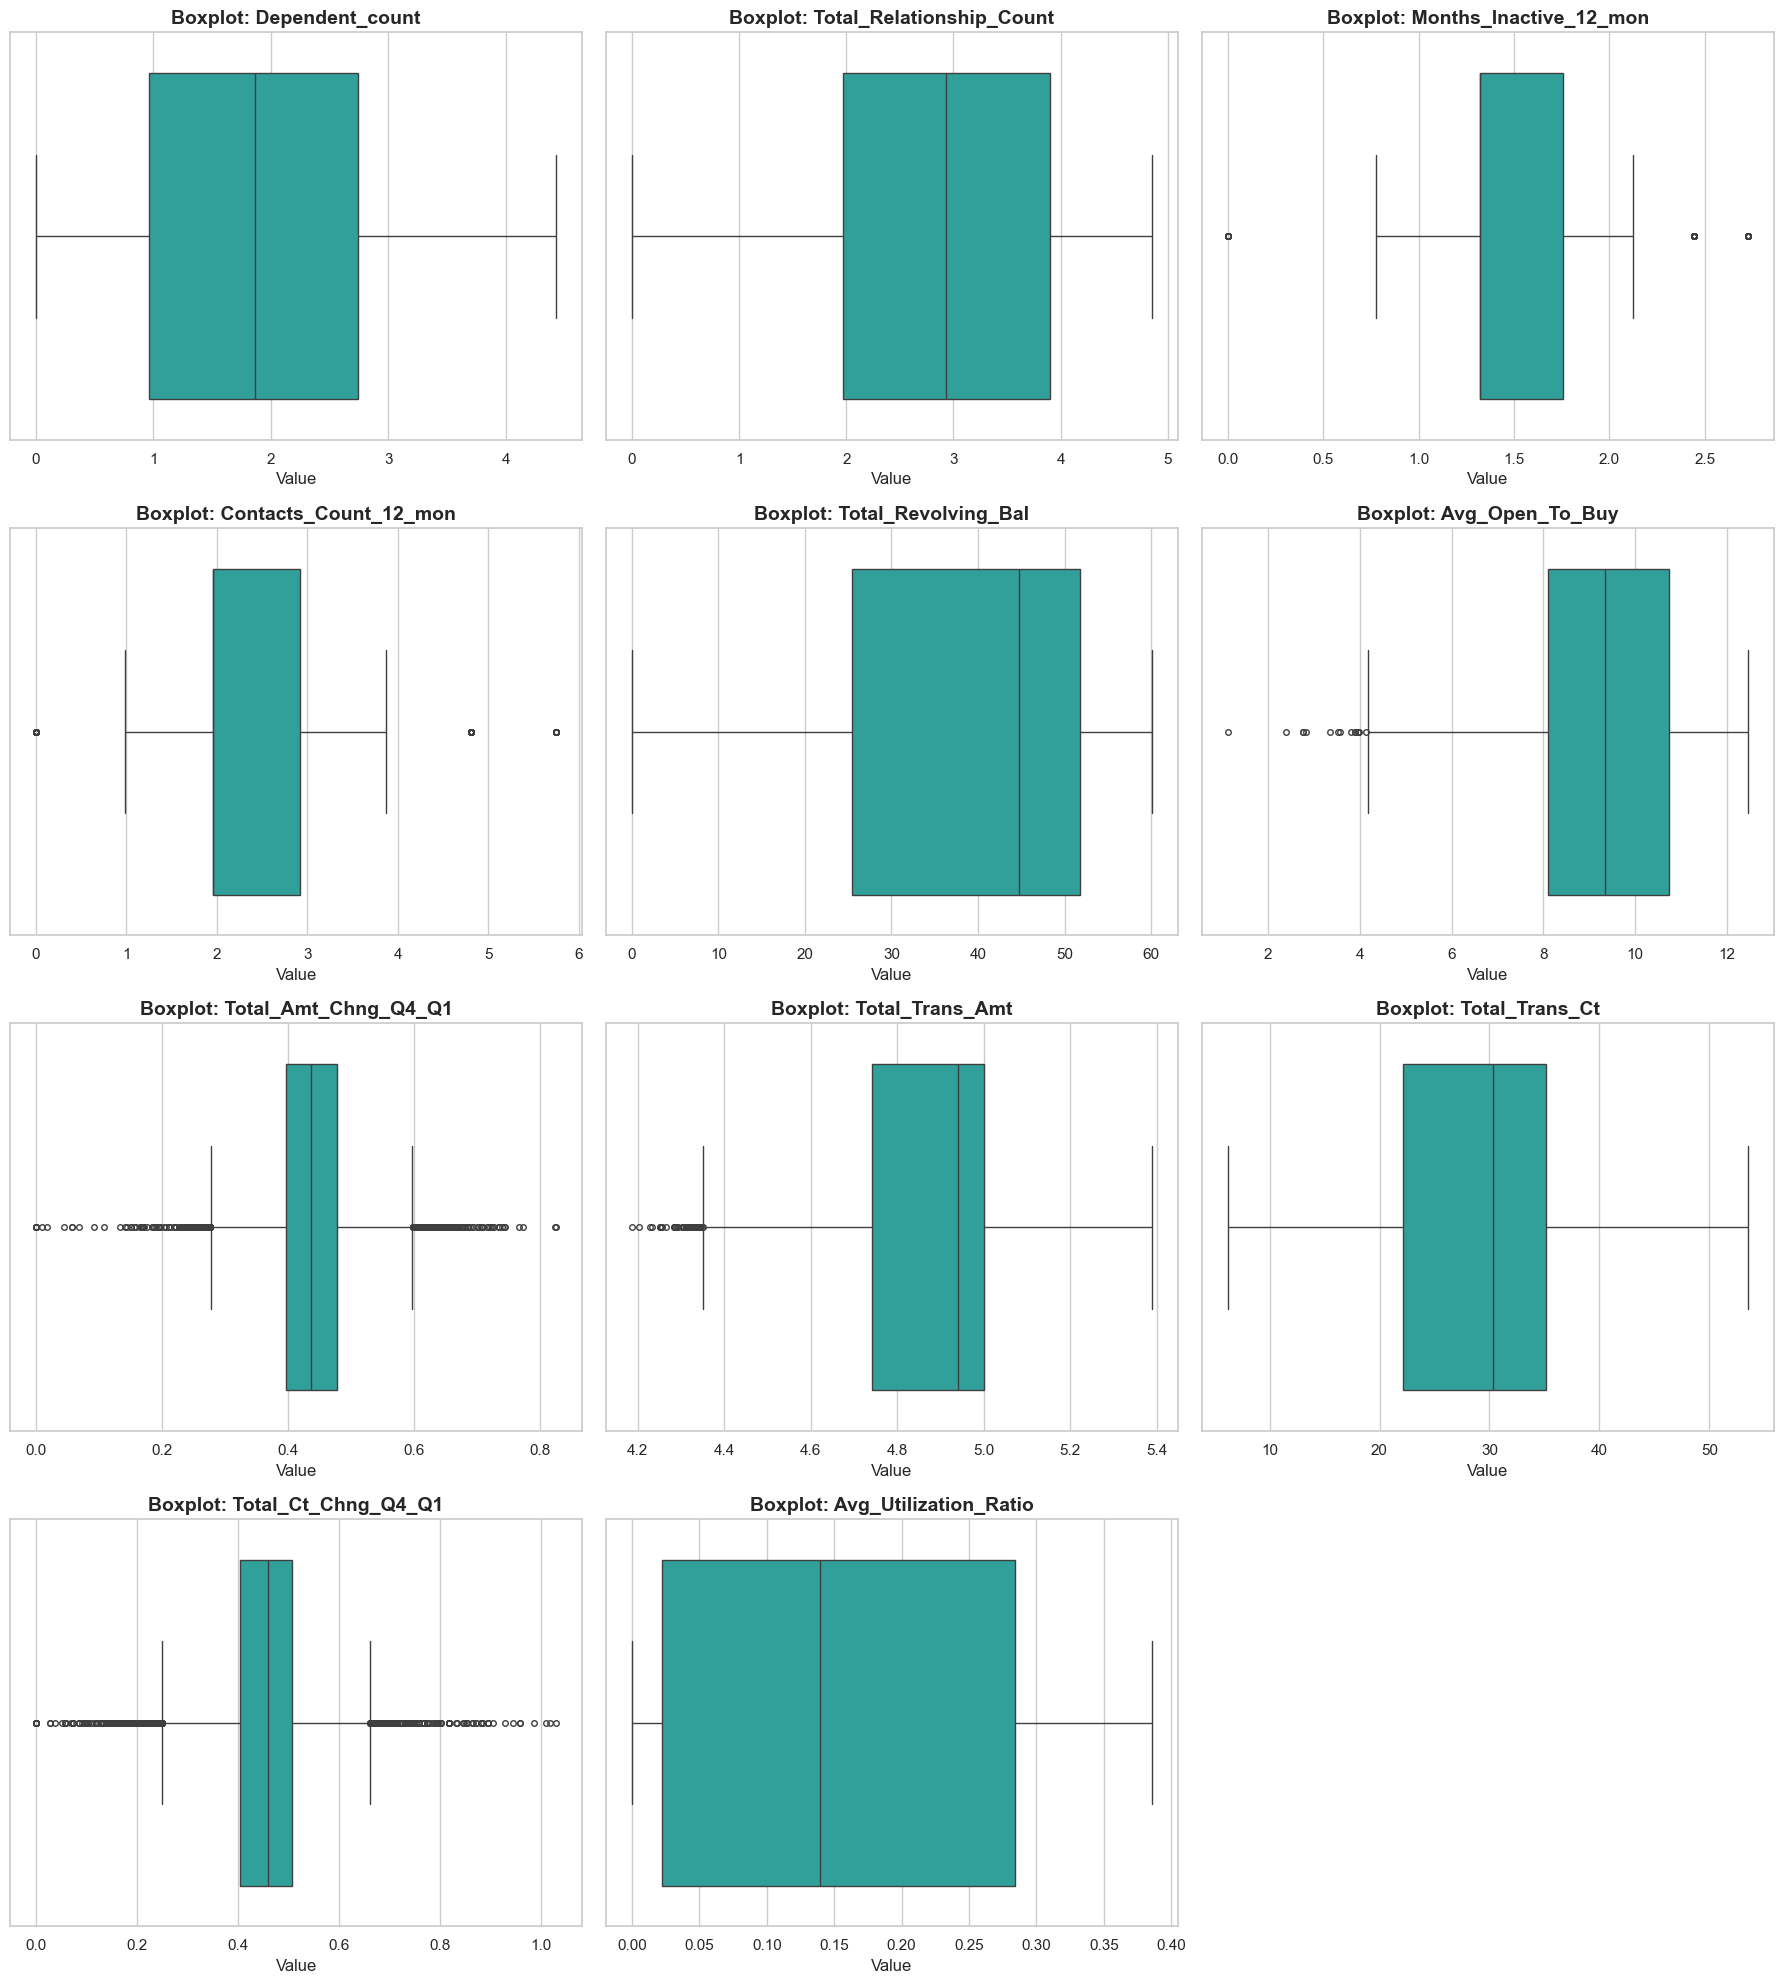

In [37]:
sns.set_theme(style="whitegrid")

num_cols = data_normalized.select_dtypes(include=[np.number]).columns
n_features = len(num_cols)

n_rows = (n_features + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=data_normalized[col], ax=axes[i], color='lightseagreen', fliersize=4)
    
    axes[i].set_title(f'Boxplot: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Value')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

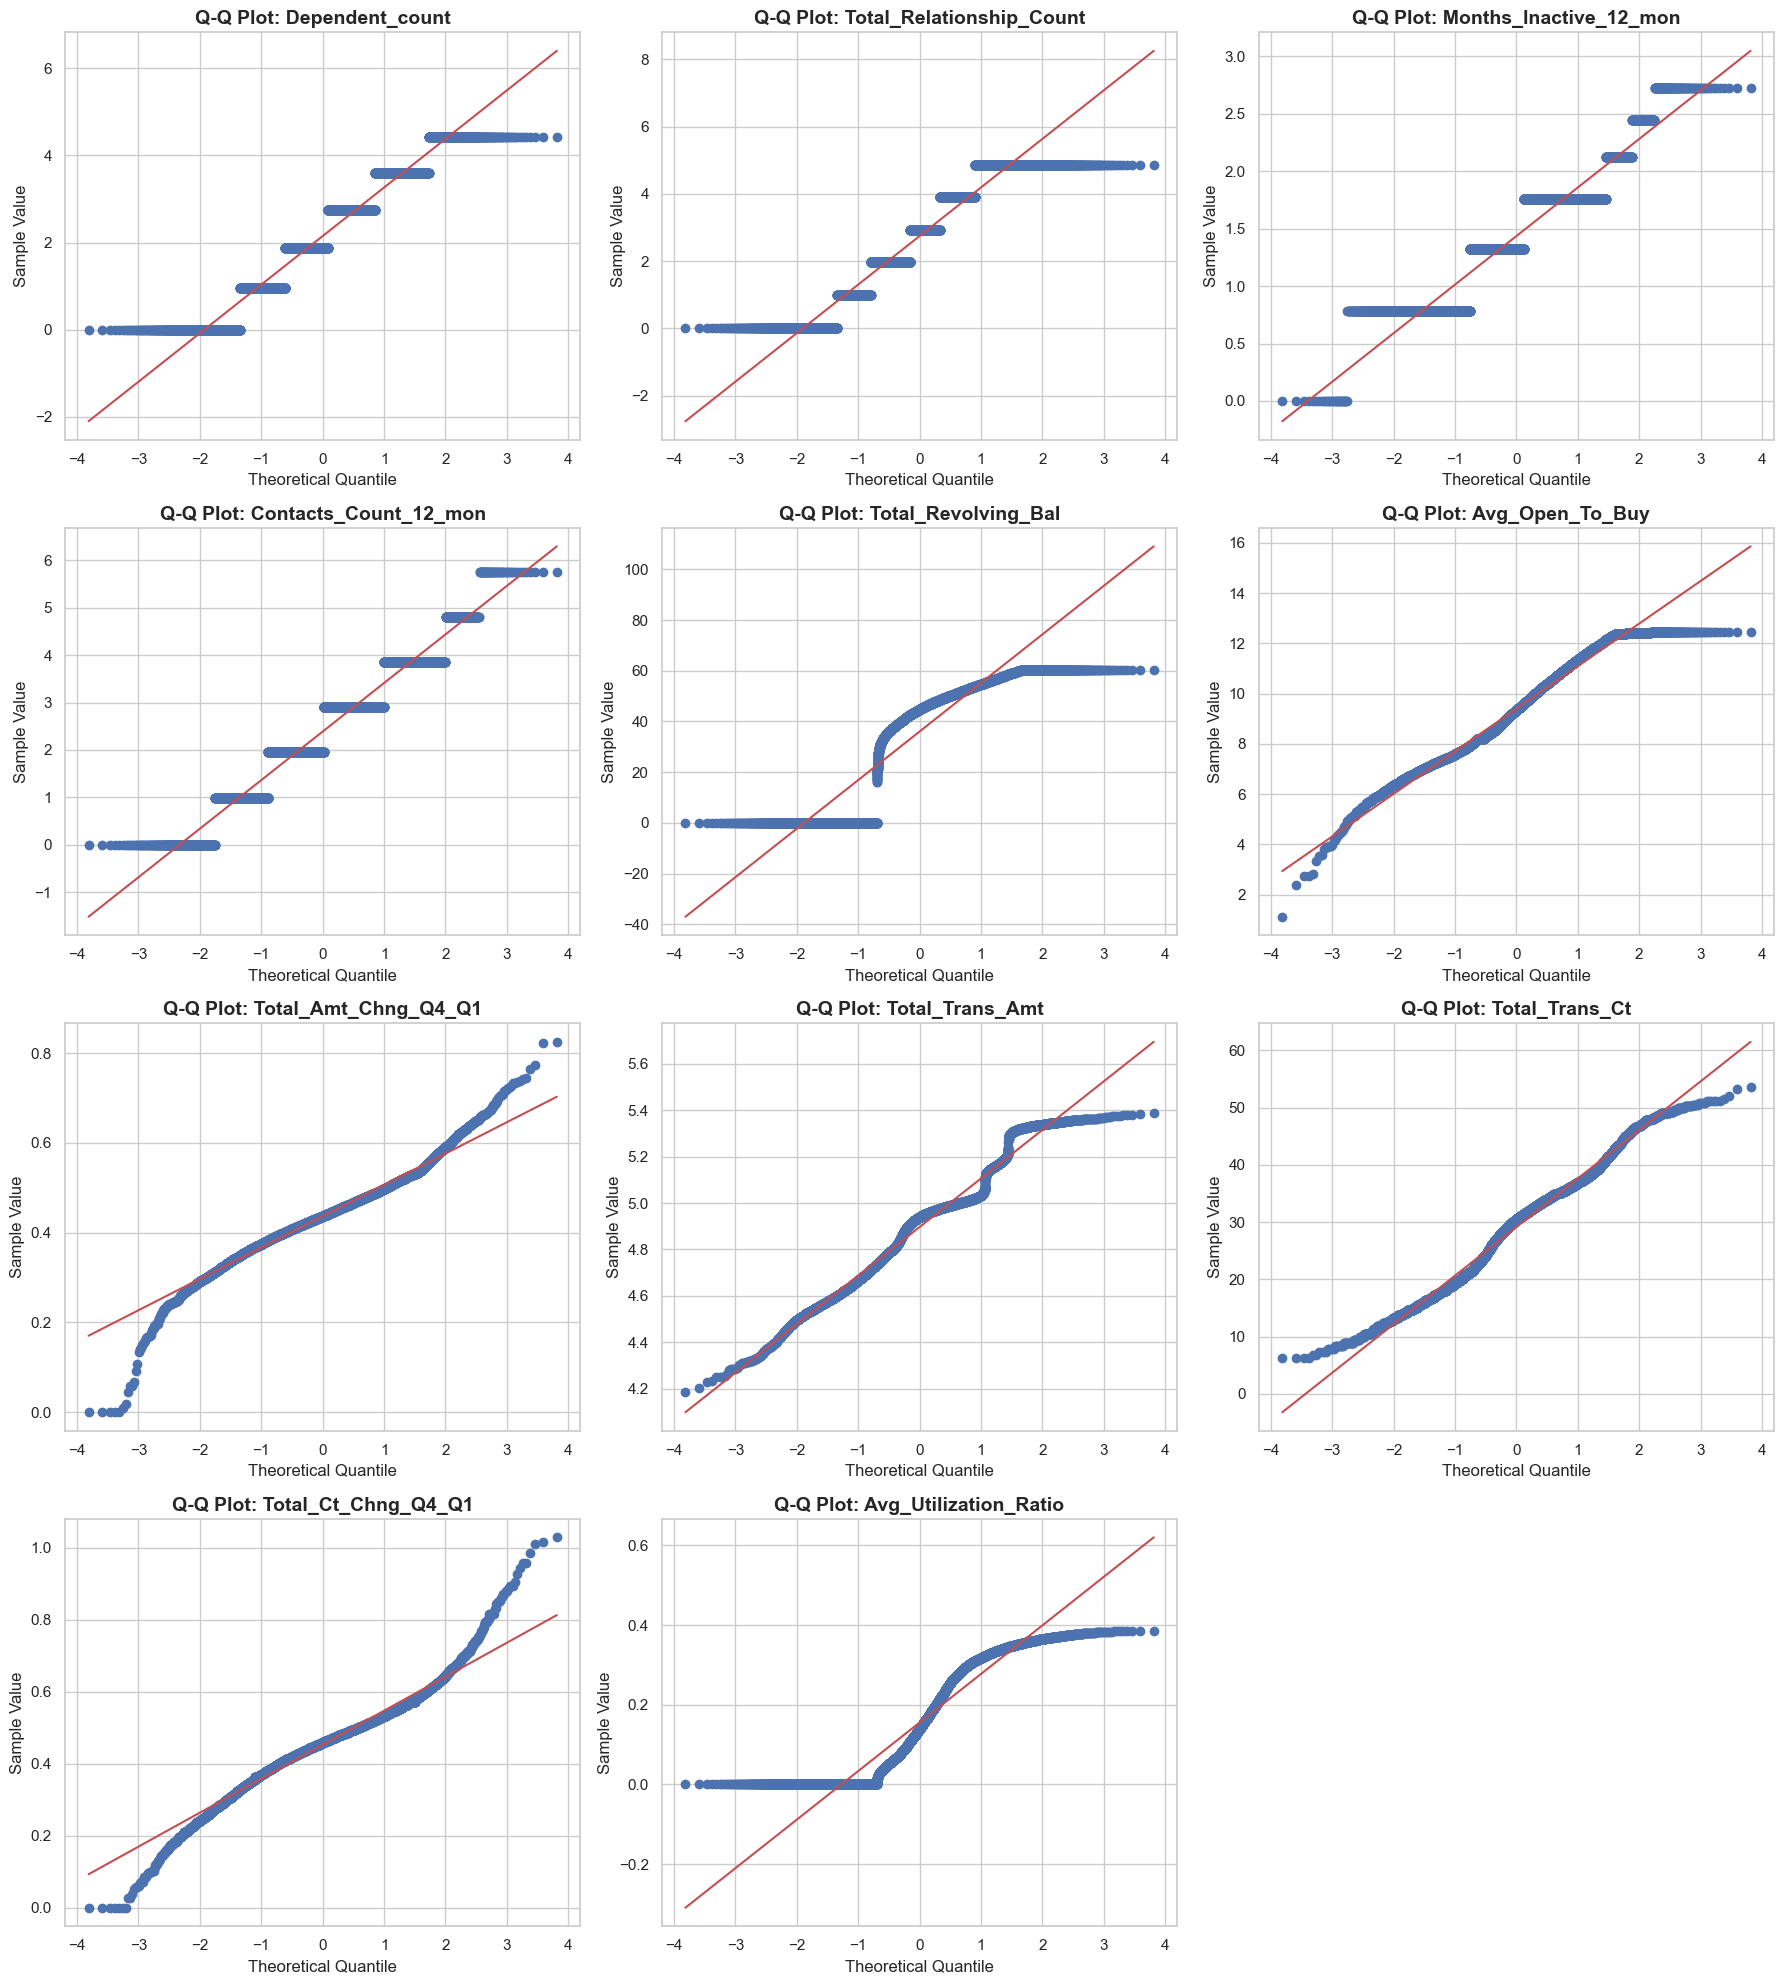

In [38]:
num_cols = data_normalized.select_dtypes(include=[np.number]).columns
n_features = len(num_cols)
n_rows = (n_features + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    stats.probplot(data_normalized[col], dist="norm", plot=axes[i])
    
    axes[i].set_title(f'Q-Q Plot: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Theoretical Quantile')
    axes[i].set_ylabel('Sample Value')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# VIII - CLASSIFIACTION 

## Baseline model - complete dataset

In [39]:

df_baseline = data.copy()

df_baseline['Attrition_Flag'] = df_baseline['Attrition_Flag'].map({
    'Existing Customer': 0, 
    'Attrited Customer': 1
})

edu_map = {'Uneducated': 0, 'High School': 1, 'College': 2, 'Unknown': 3, 'Post-Graduate': 4, 'Doctorate': 5, 'Graduate': 6}
inc_map = {'Unknown': 0, '$40K - $60K': 1, '$60K - $80K': 2, '$80K - $120K': 3, '$120K +': 4, 'Less than $40K': 5}
card_map = {'Blue': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}

df_baseline['Education_Level'] = df_baseline['Education_Level'].map(edu_map)
df_baseline['Income_Category'] = df_baseline['Income_Category'].map(inc_map)
df_baseline['Card_Category'] = df_baseline['Card_Category'].map(card_map)

df_baseline = pd.get_dummies(df_baseline, columns=['Gender', 'Marital_Status'], drop_first=True)

X_base = df_baseline.drop(columns=['Attrition_Flag', 'CLIENTNUM'])
y_base = df_baseline['Attrition_Flag']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y_base, test_size=0.2, random_state=42, stratify=y_base
)

ratio = float(np.sum(y_train_b == 0)) / np.sum(y_train_b == 1)

model_base = XGBClassifier(scale_pos_weight=ratio, random_state=42)
model_base.fit(X_train_b, y_train_b)

y_pred_b = model_base.predict(X_test_b)
print("--- BASELINE MODEL RESULTS ---")
print(classification_report(y_test_b, y_pred_b))

--- BASELINE MODEL RESULTS ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1701
           1       0.91      0.89      0.90       325

    accuracy                           0.97      2026
   macro avg       0.95      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026



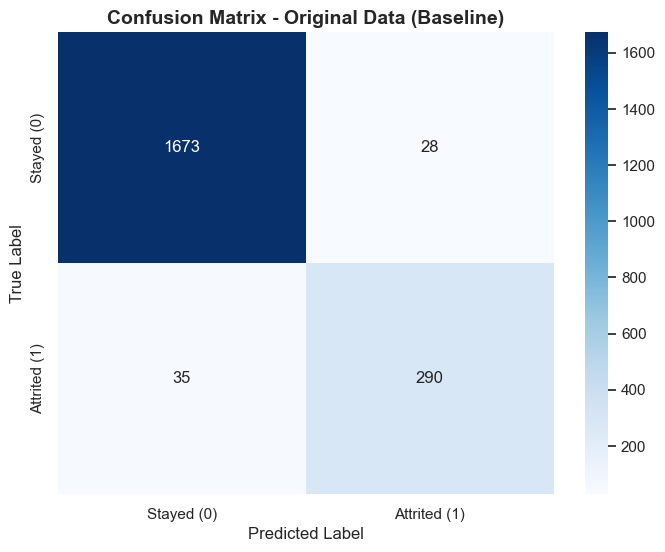

In [40]:

cm_baseline = confusion_matrix(y_test_b, y_pred_b)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Stayed (0)', 'Attrited (1)'], 
            yticklabels=['Stayed (0)', 'Attrited (1)'])

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Original Data (Baseline)', fontsize=14, fontweight='bold')
plt.show()

tn, fp, fn, tp = cm_baseline.ravel()

## Preprocessed dataset

--- FINAL MODEL RESULTS ---
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1701
           1       0.87      0.89      0.88       325

    accuracy                           0.96      2026
   macro avg       0.92      0.93      0.93      2026
weighted avg       0.96      0.96      0.96      2026



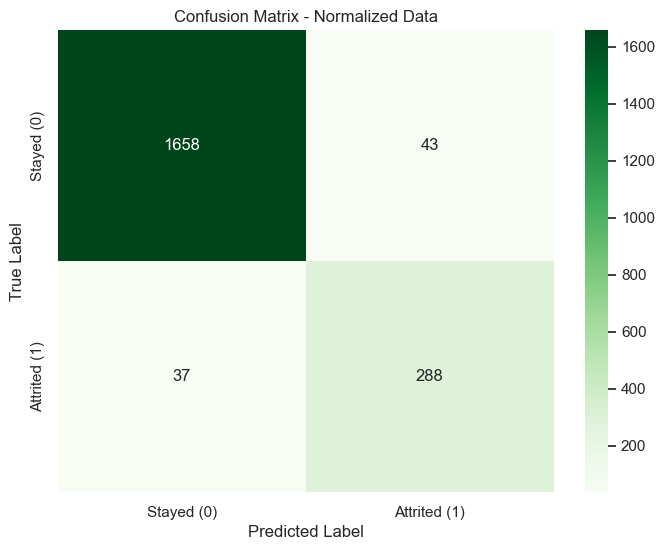

In [41]:
data_normalized['Attrition_Flag'] = data_normalized['Attrition_Flag'].map({
    'Existing Customer': 0, 
    'Attrited Customer': 1
})

X_norm = data_normalized.drop(columns=['Attrition_Flag'])
y_norm = data_normalized['Attrition_Flag']


X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_norm, y_norm, test_size=0.2, random_state=42, stratify=y_norm
)

ratio = float(np.sum(y_train_n == 0)) / np.sum(y_train_n == 1)

model_final = XGBClassifier(scale_pos_weight=ratio, random_state=42, use_label_encoder=False)
model_final.fit(X_train_n, y_train_n)

y_pred_n = model_final.predict(X_test_n)

print("--- FINAL MODEL RESULTS ---")
print(classification_report(y_test_n, y_pred_n))

cm_norm = confusion_matrix(y_test_n, y_pred_n)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Stayed (0)', 'Attrited (1)'], 
            yticklabels=['Stayed (0)', 'Attrited (1)'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Normalized Data')
plt.show()

In both cases, the classifier results are excellent and similar to each other; however, the preprocessed dataset has half the dimensionality.

# IX - CONCLUSION

## 1. Completeness
    "Unknown" values were observed in certain categorical attributes, indicating incompleteness within the dataset.
## 2. Timeliness
    Since this involves batch processing and the specific timeframe of data collection is irrelevant to the scope of this work, the Timeliness dimension can be excluded.
## 3. Uniqueness
    The "drop duplicates" method showed that there are no duplicate entries in the dataset, positively establishing this measure.
## 4. Validity
    One of the examples proving the presence of this measure is detailed in Chapter V.
## 5. Consistency
    An example of consistency was also provided in Chapter V.
## 6. Interpretability
    In general, the column names are consistent with banking terminology, and their definitions can readily be found on the website from which the dataset was sourced.
## 7. Believability
    None of the tests conducted in this study revealed any inconsistencies or reasons to doubt the credibility of the dataset. The section on outliers hinted at potential extremes that would likely be audited in a real-world practice.
## 8. Accuracy
    By reviewing the value ranges of the columns and utilizing the Mahalanobis distance for outlier detection, it was determined that the samples within the attributes possess values consistent with real-world data.

## Of course, given the large size of the dataset, there remains further potential for uncovering a broader perspective and deeper investigation into these dimensions.

# X - ADDICION: AUTO ML

In [50]:
import h2o
from h2o.automl import H2OAutoML

h2o.init()

train_pd, test_pd = train_test_split(data_normalized, test_size=0.2, random_state=42, stratify=data_normalized['Attrition_Flag'])

train_hf = h2o.H2OFrame(train_pd)
test_hf = h2o.H2OFrame(test_pd)

train_hf['Attrition_Flag'] = train_hf['Attrition_Flag'].asfactor()
test_hf['Attrition_Flag'] = test_hf['Attrition_Flag'].asfactor()

y = "Attrition_Flag"
x = train_hf.columns
x.remove(y)

aml = H2OAutoML(max_models=10, seed=42)
aml.train(x=x, y=y, training_frame=train_hf, leaderboard_frame=test_hf)

lb = aml.leaderboard
print(lb.head(rows=lb.nrows)) 

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
; Java HotSpot(TM) Client VM (build 25.441-b07, mixed mode, sharing)
  Starting server from C:\Users\Korisnik\anaconda3\Lib\site-packages\h2o\backend\bin\h2o.jar
  Ice root: C:\Users\Korisnik\AppData\Local\Temp\tmpcyjgsw8g
  JVM stdout: C:\Users\Korisnik\AppData\Local\Temp\tmpcyjgsw8g\h2o_Korisnik_started_from_python.out
  JVM stderr: C:\Users\Korisnik\AppData\Local\Temp\tmpcyjgsw8g\h2o_Korisnik_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Europe/Prague
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 28 days
H2O_cluster_name:,H2O_from_python_Korisnik_wd2h1e
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,247.5 Mb
H2O_cluster_total_cores:,12
H2O_cluster_allowed_cores:,12
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
17:41:51.617: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%
model_id                                                      auc    logloss     aucpr    mean_per_class_error      rmse        mse
StackedEnsemble_AllModels_1_AutoML_1_20260221_174151     0.991029  0.0898886  0.956629               0.0675738  0.162718  0.0264773
GBM_5_AutoML_1_20260221_174151                           0.991023  0.0914552  0.955913               0.0658102  0.162351  0.026358
GBM_3_AutoML_1_20260221_174151                           0.990515  0.0956755  0.952251               0.0787745  0.167732  0.0281342
GBM_2_AutoML_1_20260221_174151                           0.990483  0.0933487  0.95686                0.0589309  0.164522  0.0

In [51]:
h2o.cluster().shutdown()

H2O session _sid_a2c1 was not closed properly.
